*Stored run (2026-09-29).* This is `robustness.ipynb` executed with `FULL = True` (50 seeds per point for §4.4 and the §4.5 SNR sweep, 20 per point for the other sweeps, the H1 correction on 20 draws at 30 and 35 dB), 73 min on 10 cores. It was executed in a scratch copy of `code/`; the printed paths are shown relative to the repository, and its four figures are stored in `figs/extra/` as `r_full_gmm_sweeps.pdf`, `r_full_gmm_central.pdf`, `r_full_deconv_snr.pdf` and `r_full_deconv_sweeps.pdf`. The paper quotes only the fast (20-draw) run, `code/robustness.ipynb`.

# Robustness of the two experiments of §4.4 and §4.5

The paper reports one sample for the planar mixture of §4.4 and a 23-case noise sweep for the
signed deconvolution of §4.5. This notebook repeats both pipelines over many random draws, with the
paper's configuration as the central point, and measures how the reported numbers vary.

* **§4.4 (mixture).** Flat-extraction success rate and position / weight errors over seeds; dependence on
  the sample size $n$, the band $1/\tau$, the separation of the atoms, the radius of the configuration
  and the smallest weight; the H1 / H2 Christoffel strengthenings on and off.
* **§4.5 (deconvolution).** Success rate per SNR with Wilson intervals; separation between the
  opposite-sign spikes; number of spikes; grid size; the degree of the moment fit; the H1 rescue
  at $30$ dB over several noise draws.

The pipelines are copied from `fig_blasso_2dgmm.ipynb` and `fig_deconv_2d.ipynb` (same estimators,
SDPs, solvers, tolerances and extraction), only rewritten as functions of the configuration.
Section 2 and section 6 check that the copies reproduce the paper's draws.

`FULL=False` (default) runs the fast version; `FULL=True` raises the number of seeds and runs the
H1 rescue on 20 draws at $30$ and $35$ dB (about 2 h of solver time). Figures go to `../figs/extra/r_*.pdf`.

## 1. Configuration

Seeds. Mixture: seed $s$ draws the sample with `default_rng(s)`; seed $0$ is the paper's sample.
Deconvolution: seed $s$ draws the noise with `default_rng(100+s)`, the convention of the paper's sweep
(cell 22 of `fig_deconv_2d.ipynb`), so the paper's sweep cases are among ours; the noise vector of a
seed is the same at every SNR (only rescaled). The paper's own draws (`default_rng(0)` at $40$ dB,
`default_rng(1)` at $30$ dB) are run separately.

Success criteria. Mixture: the flat extraction returns exactly $s$ atoms (`flat`); `accurate` adds
max position error $\le0.1$ ($=\sigma/3$) and max weight error $\le0.05$. Deconvolution: $y_+$ gives the
number of positive spikes and $y_-$ the number of negative ones (the criterion of the paper's sweep);
`accurate` adds max position error $\le0.05$ ($=\sigma/2$) and max amplitude error $\le0.1$.
Intervals are Wilson $95\%$ intervals.

In [1]:
FULL   = True           # True: more seeds and the full H1 rescue study (about 2 h of solver time)
N_JOBS = 4              # joblib workers (each task is one independent draw; results do not depend on it)

import os, sys, math, time, itertools, warnings, json, platform
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import cvxpy as cp
import joblib
from joblib import Parallel, delayed

GMM_SEEDS   = 50 if FULL else 20      # mixture: seeds per configuration
DEC_SEEDS   = 50 if FULL else 20      # deconvolution: seeds per SNR
DEC_SEEDS_S = 20 if FULL else 10      # deconvolution: seeds per point of the other sweeps
H1_SEEDS    = 20 if FULL else 3       # deconvolution: sweep seeds for the H1 rescue (plus the paper's draw)
H1_SNRS     = (30, 35) if FULL else (30,)

FIGS = os.path.abspath("../figs/extra" if os.path.basename(os.getcwd())=="code" else "figs/extra")
os.makedirs(FIGS, exist_ok=True)
PNG_DIR = os.environ.get("R_PNG_DIR")          # optional PNG copies of the figures (not in figs/)
JSON_OUT = os.environ.get("R_JSON_OUT")        # optional dump of the aggregated results
T_START = time.time()
print(f"Python {platform.python_version()} | numpy {np.__version__} | cvxpy {cp.__version__} | "
      f"matplotlib {matplotlib.__version__} | joblib {joblib.__version__}")
print(f"FULL={FULL}: GMM_SEEDS={GMM_SEEDS}, DEC_SEEDS={DEC_SEEDS}, DEC_SEEDS_S={DEC_SEEDS_S}, "
      f"H1_SEEDS={H1_SEEDS}, H1_SNRS={H1_SNRS}; figures -> {FIGS}")

Python 3.13.3 | numpy 2.3.3 | cvxpy 1.9.1 | matplotlib 3.10.6 | joblib 1.5.2
FULL=True: GMM_SEEDS=50, DEC_SEEDS=50, DEC_SEEDS_S=20, H1_SEEDS=20, H1_SNRS=(30, 35); figures -> figs/extra


In [2]:
def wilson(k, n, z=1.96):
    # Wilson score interval for k successes out of n
    if n == 0: return (np.nan, np.nan, np.nan)
    p = k/n; den = 1 + z*z/n; c = (p + z*z/(2*n))/den
    h = z*math.sqrt(p*(1-p)/n + z*z/(4*n*n))/den
    return p, max(0.0, c-h), min(1.0, c+h)

def pmap(fun, args):
    # run fun(*a) for a in args on N_JOBS workers; returns the list of results and the wall time
    t0 = time.time()
    out = Parallel(n_jobs=N_JOBS)(delayed(fun)(*a) for a in args)
    return out, time.time() - t0

def q(v, qs=(0, 25, 50, 75, 100), fmt="{:.3g}"):
    # compact quantile summary of a sample (nan ignored)
    v = np.asarray([x for x in v if x is not None and np.isfinite(x)], float)
    if len(v) == 0: return "n/a"
    p = np.percentile(v, qs)
    return "min " + fmt.format(p[0]) + " | q1 " + fmt.format(p[1]) + " | med " + fmt.format(p[2]) + \
           " | q3 " + fmt.format(p[3]) + " | max " + fmt.format(p[4]) + f"  (n={len(v)})"

def savefig(fig, name):
    fig.savefig(os.path.join(FIGS, name + ".pdf"), bbox_inches="tight")
    if PNG_DIR:
        os.makedirs(PNG_DIR, exist_ok=True)
        fig.savefig(os.path.join(PNG_DIR, name + ".png"), bbox_inches="tight", dpi=110)
    print("saved", os.path.join(FIGS, name + ".pdf"))

def status_counts(logs):
    # logs: list of (tag, solver, status, message)
    out = {}
    for _, solver, status, _ in logs:
        out[f"{solver}:{status}"] = out.get(f"{solver}:{status}", 0) + 1
    return out

## 2. §4.4 pipeline (copied from `fig_blasso_2dgmm.ipynb`)

Same estimator (band-limited characteristic-function deconvolution on the $11\times11$ lattice cut to the
disk $\|\xi\|\le1/\tau$, least-squares fit of the moments of degree $\le4$), same diagonal SDP ($D=6$,
Mercer weights $\lambda_\alpha$, box localisers, $\beta=10^{-3}$, Clarabel with SCS fallback on exception),
same extraction (relative rank tolerance $3\times10^{-2}$, atoms with weight $>10^{-3}\max$ kept), same H1
loop (four re-solves, $\varepsilon=0.2$, $\rho_C=10^{-3}$, safeguard on the atom count) and same H2
constraints ($d_m=3$, $\rho_C=10^{-2}$, factor $1.5$). The only addition is a solver log (solver, status,
exception message) and the H1 atoms, which the paper notebook does not keep.

In [3]:
GCFG0 = dict(SIGMA=0.3, ATOMS=np.array([[-0.7,-0.7],[0.7,0.7],[0.7,-0.7]]),
             WEIGHTS=np.array([0.5,0.3,0.2]), BOX=1.2, N=20_000, D_ORDER=6, D_DATA=4,
             BAND=1.0, BETA=1e-3, RANK_TOL=3e-2, EPS_CDK=0.20, BETA_CDK=1e-3, N_CDK=4,
             D_MARG=3, BETA_MARG=1e-2, H2_MARGIN=0.5, SOLVE_TLIM=120.0)

def monomials_upto(deg):
    monos = [(a, t-a) for t in range(deg+1) for a in range(t+1)]
    return monos, {e: i for i, e in enumerate(monos)}

class GMM:
    def __init__(self, **kw):
        c = dict(GCFG0); c.update(kw); self.c = c
        self.MONOS, self.IDX = monomials_upto(2*c["D_ORDER"])
        self.basisD, _ = monomials_upto(c["D_ORDER"]); self.basisDm1, _ = monomials_upto(c["D_ORDER"]-1)
        self.fitcols = [self.IDX[e] for e in self.MONOS if e[0]+e[1] <= c["D_DATA"]]
        s2 = 2*c["SIGMA"]**2                                   # Gaussian-Mercer metric lambda_alpha
        self.w = np.array([1.0/(math.factorial(e[0])*math.factorial(e[1])*s2**(e[0]+e[1]))
                           for e in (self.MONOS[k] for k in self.fitcols)])
        b2 = c["BOX"]**2
        self.Tm  = self.sel_loc(self.basisD,   [(1.0,(0,0))])
        self.Tl1 = self.sel_loc(self.basisDm1, [(b2,(0,0)),(-1,(2,0))])
        self.Tl2 = self.sel_loc(self.basisDm1, [(b2,(0,0)),(-1,(0,2))])
        self.log = []

    def sel_loc(self, basis, g_terms):
        nb = len(basis); T = np.zeros((nb*nb, len(self.IDX)))
        for a, ea in enumerate(basis):
            for b, eb in enumerate(basis):
                for coeff, sh in g_terms:
                    T[a*nb+b, self.IDX[(ea[0]+eb[0]+sh[0], ea[1]+eb[1]+sh[1])]] += coeff
        return T

    def sample(self, rng, N=None):
        c = self.c; N = c["N"] if N is None else N
        comp = rng.choice(len(c["WEIGHTS"]), size=N, p=c["WEIGHTS"])
        return c["ATOMS"][comp] + c["SIGMA"]*rng.standard_normal((N, 2))

    def true_moments(self):
        c = self.c; m = np.zeros(len(self.MONOS))
        for e in self.MONOS:
            m[self.IDX[e]] = np.sum(c["WEIGHTS"]*c["ATOMS"][:,0]**e[0]*c["ATOMS"][:,1]**e[1])
        return m

    def lattice(self, band, ngrid=11):
        g = np.linspace(-band, band, ngrid); G1, G2 = np.meshgrid(g, g)
        XI = np.column_stack([G1.ravel(), G2.ravel()])
        return XI[np.sum(XI**2, axis=1) <= band**2 + 1e-9]

    def cf_fit(self, nuhat, XI):
        cols = [e for e in self.MONOS if e[0]+e[1] <= self.c["D_DATA"]]
        A = np.array([[(1j**(e[0]+e[1]))/(math.factorial(e[0])*math.factorial(e[1]))
                       *xi[0]**e[0]*xi[1]**e[1] for e in cols] for xi in XI])
        coef, *_ = np.linalg.lstsq(np.vstack([A.real, A.imag]),
                                   np.concatenate([nuhat.real, nuhat.imag]), rcond=None)
        m = np.zeros(len(self.MONOS))
        for cc, e in zip(coef, cols): m[self.IDX[e]] = cc.real
        return m

    def cf_band_moments(self, X, band):              # empirical CF / Ghat, then LS fit
        XI = self.lattice(band); s = self.c["SIGMA"]
        phihat = np.exp(1j*(X @ XI.T)).mean(axis=0)
        return self.cf_fit(phihat/np.exp(-0.5*s**2*np.sum(XI**2, axis=1)), XI)

    def cf_band_moments_exact(self, band):           # exact CF of mu^star (noiseless data)
        c = self.c; XI = self.lattice(band)
        return self.cf_fit((c["WEIGHTS"][None,:]*np.exp(1j*(XI @ c["ATOMS"].T))).sum(axis=1), XI)

    def solve(self, mhat, cdk=None, marg=None, tag=""):
        c = self.c; nbD, nbL = len(self.basisD), len(self.basisDm1); fc = self.fitcols
        yp = cp.Variable(len(self.MONOS)); ym = cp.Variable(len(self.MONOS)); diff = yp - ym
        Mp = cp.reshape(self.Tm@yp, (nbD,nbD), order="C"); Mm = cp.reshape(self.Tm@ym, (nbD,nbD), order="C")
        cons = [Mp >> 0, Mm >> 0,
                cp.reshape(self.Tl1@yp,(nbL,nbL),order="C") >> 0, cp.reshape(self.Tl2@yp,(nbL,nbL),order="C") >> 0,
                cp.reshape(self.Tl1@ym,(nbL,nbL),order="C") >> 0, cp.reshape(self.Tl2@ym,(nbL,nbL),order="C") >> 0]
        if cdk is not None:                          # H1: <W, M_D(y_+)> <= gamma
            Wcdk, gam = cdk; cons.append(cp.sum(cp.multiply(Wcdk, Mp)) <= gam)
        if marg is not None:                         # H2: marginal Christoffel localisers
            for g_terms, lo in marg:
                bLo, _ = monomials_upto(lo); nlo = len(bLo)
                cons.append(cp.reshape(self.sel_loc(bLo, g_terms)@yp, (nlo,nlo), order="C") >> 0)
        fit = 0.5*cp.sum(cp.multiply(self.w, cp.square(diff[fc] - mhat[fc])))
        prob = cp.Problem(cp.Minimize(fit + c["BETA"]*(yp[self.IDX[(0,0)]] + ym[self.IDX[(0,0)]])), cons)
        solver, status, msg = "CLARABEL", None, ""
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")      # the status is recorded instead
                prob.solve(solver=cp.CLARABEL, time_limit=c["SOLVE_TLIM"])
            status = prob.status
        except Exception as e:
            solver, msg = "SCS", f"CLARABEL: {type(e).__name__}"
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    prob.solve(solver=cp.SCS, max_iters=20000)
                status = prob.status
            except Exception as e2:
                status, msg = "failed", msg + f"; SCS: {type(e2).__name__}"
        self.log.append((tag, solver, status, msg))
        Adual = None
        try: Adual = cons[0].dual_value
        except Exception: pass
        return yp.value, ym.value, Adual

    def mm(self, y):
        nb = len(self.basisD); M = np.empty((nb, nb)); I = self.IDX
        for a, ea in enumerate(self.basisD):
            for b, eb in enumerate(self.basisD):
                M[a, b] = y[I[(ea[0]+eb[0], ea[1]+eb[1])]]
        return M

    @staticmethod
    def christoffel_weight(M, beta):                 # W=(M+beta I)^{-1}, L=tr(WM)
        W = np.linalg.inv(M + beta*np.eye(M.shape[0])); return W, float(np.sum(W*M))

    def h2_constraints(self, y, atoms):
        c = self.c; I = self.IDX; out = []
        for coord in (0, 1):
            midx = (lambda a: I[(a,0)]) if coord == 0 else (lambda a: I[(0,a)])
            dm = c["D_MARG"]
            M = np.array([[y[midx(a+b)] for b in range(dm+1)] for a in range(dm+1)])
            W = np.linalg.inv(M + c["BETA_MARG"]*np.eye(dm+1)); cc = np.zeros(2*dm+1)
            for a in range(dm+1):
                for b in range(dm+1): cc[a+b] += W[a, b]
            gam = (1.0 + c["H2_MARGIN"])*max(sum(cc[k]*a[coord]**k for k in range(len(cc))) for a in atoms)
            g_terms = [((gam - cc[0])/gam, (0,0))]
            for k in range(1, len(cc)): g_terms.append((-cc[k]/gam, (k,0) if coord == 0 else (0,k)))
            out.append((g_terms, c["D_ORDER"] - dm))
        return out

    @staticmethod
    def _rref_pivots(M, tol):
        A = M.copy().astype(float); nrow, ncol = A.shape; piv, row = [], 0
        for col in range(ncol):
            if row >= nrow: break
            p = row + np.argmax(np.abs(A[row:, col]))
            if abs(A[p, col]) <= tol: continue
            A[[row, p]] = A[[p, row]]; A[row] /= A[row, col]
            for rr in range(nrow):
                if rr != row: A[rr] -= A[rr, col]*A[row]
            piv.append(col); row += 1
        return piv

    def extract(self, M):                            # Curto-Fialkow flat extraction
        tol = self.c["RANK_TOL"]; basisD = self.basisD; Dorder = self.c["D_ORDER"]
        pos = {e: i for i, e in enumerate(basisD)}; deg = [e[0]+e[1] for e in basisD]
        s = np.linalg.svd(M, compute_uv=False); rank = int(np.sum(s > tol*s[0]))
        if rank < 1: raise RuntimeError("zero rank")
        piv = [p for p in self._rref_pivots(M, tol*s[0]) if deg[p] <= Dorder-1]
        piv = sorted(piv, key=lambda i: (deg[i], i))
        if len(piv) < rank: raise RuntimeError(f"not flat: rank {rank}, {len(piv)} low-deg pivots")
        pivots = piv[:rank]; B = [basisD[i] for i in pivots]; Mpp = M[np.ix_(pivots, pivots)]
        mult = []
        for k in range(2):
            Nk = np.zeros((rank, rank))
            for j, be in enumerate(B):
                sh = (be[0]+(1 if k == 0 else 0), be[1]+(1 if k == 1 else 0)); si = pos.get(sh)
                if si is None: raise RuntimeError("shift outside basis")
                Nk[:, j] = np.linalg.solve(Mpp, np.array([M[pivots[i], si] for i in range(rank)]))
            mult.append(Nk)
        g = np.random.default_rng(1).standard_normal(2)
        _, V = np.linalg.eig(g[0]*mult[0] + g[1]*mult[1]); Vi = np.linalg.inv(V)
        coords = np.column_stack([np.real(np.diag(Vi@mult[k]@V)) for k in range(2)])
        Phi = np.array([[a[0]**e[0]*a[1]**e[1] for a in coords] for e in B], float)
        w, *_ = np.linalg.lstsq(Phi, np.array([M[pivots[i], pos[(0,0)]] for i in range(rank)]), rcond=None)
        return coords, w

    def extract_kept(self, M):
        a, wt = self.extract(M); keep = wt > 1e-3*np.max(np.abs(wt)); return a[keep], wt[keep]

    def eta(self, mhat, yp, ym, P):                  # subgradient certificate at the points P
        diff = yp - ym; out = np.zeros(len(P))
        for k, wk in zip(self.fitcols, self.w):
            e = self.MONOS[k]; out += wk*(mhat[k] - diff[k])/self.c["BETA"]*P[:,0]**e[0]*P[:,1]**e[1]
        return out

In [4]:
def match(true_a, true_w, rec_a, rec_w):
    # injective assignment true -> recovered minimising the max position error;
    # returns dict(dpos, dw, per-atom arrays, unmatched indices) or None if too few atoms
    k = len(true_a)
    if rec_a is None or len(rec_a) < k: return None
    best = None
    for perm in itertools.permutations(range(len(rec_a)), k):
        d = np.array([np.hypot(*(rec_a[p] - t)) for p, t in zip(perm, true_a)])
        if best is None or d.max() < best[0].max(): best = (d, perm)
    d, perm = best; dw = np.array([abs(rec_w[p] - w) for p, w in zip(perm, true_w)])
    return dict(dpos=float(d.max()), dw=float(dw.max()), d=d, dws=dw, perm=perm,
                unmatched=[i for i in range(len(rec_a)) if i not in perm])

def gmm_task(over, seed, h=False, noiseless=False, cert=False):
    # one draw of the §4.4 experiment; returns a small dict of diagnostics
    G = GMM(**over); c = G.c; t0 = time.time(); s = len(c["ATOMS"])
    mt = G.true_moments(); fc = G.fitcols
    mex = G.cf_band_moments_exact(c["BAND"])
    if noiseless: mhat = mex
    else: mhat = G.cf_band_moments(G.sample(np.random.default_rng(seed)), c["BAND"])
    out = dict(seed=seed, mom_err=float(np.max(np.abs(mhat[fc]-mt[fc]))),
               mom_noise=float(np.max(np.abs(mhat[fc]-mex[fc]))), m0=float(mhat[0]))
    yp, ym, Adual = G.solve(mhat, tag="base")
    if yp is None:
        out.update(n_atoms=0, flat=False, err="no solution", log=G.log, time=time.time()-t0); return out
    Mp = G.mm(yp); sv = np.linalg.svd(Mp, compute_uv=False); sv = sv/sv[0]
    out.update(sv=sv[:8].tolist(), L=G.christoffel_weight(Mp, 1e-3)[1],
               ymass=float(ym[0]/(yp[0]+ym[0])))
    n0 = 0; atoms = weights = None
    try:
        atoms, weights = G.extract_kept(Mp); n0 = len(atoms); out["err"] = None
    except Exception as e:
        out["err"] = str(e)
    out.update(n_atoms=n0, flat=(n0 == s), atoms=None if atoms is None else atoms.tolist(),
               weights=None if weights is None else weights.tolist())
    m = match(c["ATOMS"], c["WEIGHTS"], atoms, weights)
    if m is not None:
        out.update(dpos=m["dpos"], dw=m["dw"], d_each=m["d"].tolist(),
                   radial=[float(np.linalg.norm(t) - np.linalg.norm(atoms[p])) for p, t in zip(m["perm"], c["ATOMS"])],
                   spurious=[(atoms[i].tolist(), float(weights[i])) for i in m["unmatched"]])
    if cert:
        g = np.linspace(-c["BOX"], c["BOX"], 161); XX, YY = np.meshgrid(g, g)
        P = np.column_stack([XX.ravel(), YY.ravel()]); e = G.eta(mhat, yp, ym, P)
        out["eta_max"] = float(e.max()); out["eta_at_true"] = G.eta(mhat, yp, ym, c["ATOMS"]).tolist()
        line = lambda x1: G.eta(mhat, yp, ym, np.column_stack([np.full(161, x1), g]))
        out["eta_line07_dev"] = float(1 - line(0.7).min())
        out["eta_bestline_dev"] = float(min(1 - line(x1).min() for x1 in np.arange(0.60, 0.8001, 0.005)))
        away = np.min(np.linalg.norm(P[:,None,:] - c["ATOMS"][None], axis=2), axis=1) > 0.15
        i = int(np.argmax(np.where(away, e, -np.inf)))
        out["eta_away_max"] = float(e[i]); out["eta_away_at"] = P[i].tolist()
        out["eta_near1_frac"] = float(np.mean(e[away] > 1 - 3e-3))   # share of X (away from atoms) where eta > 1-3e-3
        out["eta_away_dist"] = float(np.min(np.linalg.norm(c["ATOMS"] - P[i], axis=1)))
        out["eta_empty_corner"] = float(G.eta(mhat, yp, ym, np.array([[-0.7, 0.7]]))[0])   # the fourth corner of the square
    if h:
        # H1, exactly as run("smooth") of the paper notebook, keeping the atoms of the last accepted iterate
        yp_s = yp.copy(); a_h1, w_h1 = atoms, weights; nacc = 0
        for it in range(c["N_CDK"]):
            Ws, Ls = G.christoffel_weight(G.mm(yp_s), c["BETA_CDK"])
            o = G.solve(mhat, cdk=(Ws, (1.0-c["EPS_CDK"])*Ls), tag=f"H1.{it}")
            if o[0] is None: break
            Mn = G.mm(o[0])
            try:
                a2, wt2 = G.extract(Mn)
                if int(np.sum(wt2 > 1e-3*np.max(np.abs(wt2)))) < max(n0, 1): break
            except Exception: break
            keep = wt2 > 1e-3*np.max(np.abs(wt2)); a_h1, w_h1 = a2[keep], wt2[keep]; yp_s = o[0]; nacc += 1
        out.update(h1_nacc=nacc, h1_L=G.christoffel_weight(G.mm(yp_s), c["BETA_CDK"])[1],
                   h1_n=0 if a_h1 is None else len(a_h1))
        out["h1_flat"] = out["h1_n"] == s
        m1 = match(c["ATOMS"], c["WEIGHTS"], a_h1, w_h1)
        if m1 is not None:
            out.update(h1_dpos=m1["dpos"], h1_dw=m1["dw"])
            if atoms is not None and len(atoms) >= s and m is not None:
                out["h1_move"] = float(max(np.hypot(*(a_h1[p1] - atoms[p0])) for p0, p1 in zip(m["perm"], m1["perm"])))
        # H2 from the base iterate and the base atoms
        out["h2_n"] = 0
        if atoms is not None and n0 > 0:
            o2 = G.solve(mhat, marg=G.h2_constraints(yp, atoms), tag="H2")
            if o2[0] is not None:
                M2 = G.mm(o2[0]); out["h2_L"] = G.christoffel_weight(M2, 1e-3)[1]
                try:
                    a3, w3 = G.extract_kept(M2); out["h2_n"] = len(a3)
                    m2 = match(c["ATOMS"], c["WEIGHTS"], a3, w3)
                    if m2 is not None:
                        out.update(h2_dpos=m2["dpos"], h2_dw=m2["dw"])
                        if m is not None:
                            out["h2_move"] = float(max(np.hypot(*(a3[p2] - atoms[p0])) for p0, p2 in zip(m["perm"], m2["perm"])))
                except Exception as e:
                    out["h2_err"] = str(e)
        out["h2_flat"] = out["h2_n"] == s
    out["log"] = G.log; out["time"] = time.time() - t0
    return out

**Reproduction check.** Seed $0$ at the paper's configuration must return the numbers of §4.4
(rank surrogate $8.01\to4.74$ (H1), $5.90$ (H2); positions to $0.05$, weights to $0.02$; at band $6$ four
atoms, $\widehat m_0=0.60$, spurious atom at $(-0.60,0.59)$).

In [5]:
r0 = gmm_task({}, 0, h=True, cert=True)
r6 = gmm_task({"BAND": 6.0}, 0, cert=True)
print(f"band 1, seed 0: {r0['n_atoms']} atoms, dpos={r0['dpos']:.3f}, dw={r0['dw']:.3f}, sv[:4]={np.round(r0['sv'][:4],4)}, "
      f"L={r0['L']:.2f} -> H1 {r0['h1_L']:.2f} ({r0['h1_nacc']} accepted), H2 {r0['h2_L']:.2f}; "
      f"H1 move {r0['h1_move']:.4f}, H2 move {r0['h2_move']:.4f}; H1 dpos {r0['h1_dpos']:.4f}, H2 dpos {r0['h2_dpos']:.4f}")
print(f"   moment error {r0['mom_err']:.4f} (noise part {r0['mom_noise']:.4f}); y_- mass share {r0['ymass']:.4f}; "
      f"eta: max {r0['eta_max']:.5f}, 1-min on x1=0.7 {r0['eta_line07_dev']:.2e}")
print(f"band 6, seed 0: {r6['n_atoms']} atoms, m0={r6['m0']:.4f}, moment error {r6['mom_err']:.3f} (noise part {r6['mom_noise']:.4f}), "
      f"pulls {np.round(r6['d_each'],3)}, spurious {r6['spurious']}")
print("solver log (seed 0, band 1):", status_counts(r0["log"]))
assert abs(r0["L"]-8.01) < 0.01 and abs(r0["h1_L"]-4.74) < 0.01 and abs(r0["h2_L"]-5.90) < 0.01
assert r0["n_atoms"] == 3 and r6["n_atoms"] == 4 and abs(r6["m0"]-0.60) < 0.005

band 1, seed 0: 3 atoms, dpos=0.048, dw=0.017, sv[:4]=[1.     0.566  0.2308 0.0149], L=8.01 -> H1 4.74 (4 accepted), H2 5.90; H1 move 0.0039, H2 move 0.0043; H1 dpos 0.0452, H2 dpos 0.0521
   moment error 0.0120 (noise part 0.0051); y_- mass share 0.0146; eta: max 1.00000, 1-min on x1=0.7 2.72e-03
band 6, seed 0: 4 atoms, m0=0.5996, moment error 0.400 (noise part 0.0048), pulls [0.133 0.134 0.14 ], spurious [([-0.5991244559872542, 0.5873694698706209], 0.04657756329585101)]
solver log (seed 0, band 1): {'CLARABEL:optimal_inaccurate': 6}


## 3. §4.4 at the paper's configuration, over seeds

Band $1$ with H1 and H2 on every seed, band $6$ base only, and both bands on noiseless data
(exact characteristic function). Each quoted number of §4.4 is set against its distribution.

In [6]:
central, tw1 = pmap(gmm_task, [({}, s, True, False, True) for s in range(GMM_SEEDS)])
broad,   tw2 = pmap(gmm_task, [({"BAND": 6.0}, s, False, False, True) for s in range(GMM_SEEDS)])
nl1 = gmm_task({}, 0, h=True, noiseless=True, cert=True)
nl6 = gmm_task({"BAND": 6.0}, 0, noiseless=True, cert=True)
print(f"{GMM_SEEDS} seeds; wall time {tw1:.0f} s (band 1, H1+H2) and {tw2:.0f} s (band 6)")

def col(rs, k): return [r.get(k, np.nan) if r.get(k) is not None else np.nan for r in rs]
def rate_str(rs, k="flat"):
    x = sum(bool(r.get(k)) for r in rs); p, lo, hi = wilson(x, len(rs)); return f"{x}/{len(rs)} [{lo:.2f}, {hi:.2f}]"

print("\n--- band 1 (paper: rank-3 plateau, positions to 0.05, weights to 0.02) ---")
print("flat 3-atom extraction:", rate_str(central))
print("max position error   :", q(col(central, "dpos")), f"| noiseless {nl1['dpos']:.4f}")
print("max weight error     :", q(col(central, "dw")),   f"| noiseless {nl1['dw']:.4f}")
print("s3/s1                :", q([r["sv"][2] for r in central]))
print("s4/s1 (tol 3e-2)     :", q([r["sv"][3] for r in central]), f"| noiseless {nl1['sv'][3]:.4f}")
print("moment error total   :", q(col(central, "mom_err")), f"| noiseless (bias) {nl1['mom_err']:.4f}")
print("moment error noise   :", q(col(central, "mom_noise")))
print("y_- mass share       :", q(col(central, "ymass")))
print("\n--- H1 / H2 (paper, §4.4: L 8.01 -> 4.74 / 5.90 for this sample, median over samples; H1 lowers the position error, raises the weight error in a quarter) ---")
print("L base               :", q(col(central, "L")))
print("L H1                 :", q(col(central, "h1_L")), "| accepted re-solves:", q(col(central, "h1_nacc")))
print("L H2                 :", q(col(central, "h2_L")))
print("H1 move              :", q(col(central, "h1_move")))
print("H2 move              :", q(col(central, "h2_move")))
d1 = np.array(col(central, "h1_dpos")) - np.array(col(central, "dpos"))
d2 = np.array(col(central, "h2_dpos")) - np.array(col(central, "dpos"))
print(f"H1 better (smaller max dpos) in {np.sum(d1<0)}/{np.sum(np.isfinite(d1))} seeds; change {q(d1)}")
print(f"H2 worse  (larger  max dpos) in {np.sum(d2>0)}/{np.sum(np.isfinite(d2))} seeds; change {q(d2)}")
print("H1 flat / H2 flat    :", rate_str(central, "h1_flat"), "/", rate_str(central, "h2_flat"))
print("\n--- certificate at band 1 (paper: for this sample within 2.7e-3 of 1 along the whole line x1 ~ 0.7) ---")
print("1 - min eta on x1=0.7        :", q(col(central, "eta_line07_dev")), f"| noiseless {nl1['eta_line07_dev']:.2e}")
print("same, best line x1 in [.6,.8]:", q(col(central, "eta_bestline_dev")))
print("max eta on X (161^2)         :", q(col(central, "eta_max"), fmt="{:.5f}"))
print("max eta at distance > 0.15 from the atoms:", q(col(central, "eta_away_max"), fmt="{:.5f}"), f"| noiseless {nl1['eta_away_max']:.5f}")
print("share of X (away) with eta > 1-3e-3      :", q(col(central, "eta_near1_frac")), f"| noiseless {nl1['eta_near1_frac']:.3f}")
print("distance of that maximum to the nearest atom:", q(col(central, "eta_away_dist")),
      f"| > 0.5 in {sum(r['eta_away_dist'] > 0.5 for r in central)}/{GMM_SEEDS} seeds")
print("eta at the empty corner (-0.7, 0.7)      :", q(col(central, "eta_empty_corner"), fmt="{:.5f}"))
print("max |1 - eta| at the true atoms          :", q([max(abs(1 - v) for v in r["eta_at_true"]) for r in central]))
print("\n--- band 6 (paper: 4 atoms, m0 = 0.60, bias 0.4, three atoms pulled ~0.13, spurious at (-0.60,0.59)) ---")
print("number of atoms      :", {k: [r["n_atoms"] for r in broad].count(k) for k in sorted(set(r["n_atoms"] for r in broad))})
print("m0                   :", q(col(broad, "m0"), fmt="{:.4f}"), f"| noiseless {nl6['m0']:.4f}")
print("moment error total   :", q(col(broad, "mom_err")), f"| noiseless {nl6['mom_err']:.4f}")
print("moment error noise   :", q(col(broad, "mom_noise")))
nb_less = sum(b["mom_noise"] < c_["mom_noise"] for b, c_ in zip(broad, central))
print(f"noise part at band 6 < band 1 in {nb_less}/{GMM_SEEDS} seeds; ratio band6/band1 "
      f"{q([b['mom_noise']/c_['mom_noise'] for b, c_ in zip(broad, central)])}")
pulls = [x for r in broad if r.get("d_each") for x in r["d_each"]]
print("pull of the 3 atoms  :", q(pulls), "| radial part", q([x for r in broad if r.get("radial") for x in r["radial"]]))
sp = [r["spurious"][0] for r in broad if r.get("spurious")]
print("spurious atom x, y   :", q([s_[0][0] for s_ in sp]), "|", q([s_[0][1] for s_ in sp]))
print("spurious atom weight :", q([s_[1] for s_ in sp]))
print("max eta at band 6    :", q(col(broad, "eta_max"), fmt="{:.5f}"))
logs = [l for r in central + broad for l in r["log"]]
print("\nsolver statuses (all solves of this cell):", status_counts(logs))

50 seeds; wall time 182 s (band 1, H1+H2) and 8 s (band 6)

--- band 1 (paper: rank-3 plateau, positions to 0.05, weights to 0.02) ---
flat 3-atom extraction: 50/50 [0.93, 1.00]
max position error   : min 0.0352 | q1 0.0448 | med 0.049 | q3 0.0523 | max 0.0639  (n=50) | noiseless 0.0518
max weight error     : min 0.00881 | q1 0.0132 | med 0.0157 | q3 0.0171 | max 0.0218  (n=50) | noiseless 0.0158
s3/s1                : min 0.209 | q1 0.219 | med 0.223 | q3 0.228 | max 0.234  (n=50)
s4/s1 (tol 3e-2)     : min 0.00473 | q1 0.00712 | med 0.00863 | q3 0.0122 | max 0.0255  (n=50) | noiseless 0.0065
moment error total   : min 0.00655 | q1 0.0115 | med 0.0139 | q3 0.0156 | max 0.0203  (n=50) | noiseless (bias) 0.0105
moment error noise   : min 0.00292 | q1 0.00526 | med 0.00727 | q3 0.00852 | max 0.0143  (n=50)
y_- mass share       : min 0.0102 | q1 0.0118 | med 0.0127 | q3 0.0139 | max 0.0161  (n=50)

--- H1 / H2 (paper, §4.4: L 8.01 -> 4.74 / 5.90 for this sample, median over samples; H1 lo

## 4. §4.4 sweeps around the paper's configuration

One parameter at a time, the others at the paper's values; seeds $0,\dots,$`GMM_SEEDS`$-1$ and one noiseless
run per point.

* sample size $n$;
* band $1/\tau$ (the lattice keeps $81$ points in the disk);
* separation $d$: the third atom moves from $(0.7,-0.7)$ towards $(0.7,0.7)$, $t_3=(0.7,0.7-d)$, so that $d$ is
  the minimum separation while $\|t_k\|\le0.99$; $d=1.4$ is the paper's configuration;
* radius: all atoms scaled by $c$ (separation $1.4c$, $\|t_k\|=0.99c$), which moves $\max|\xi^\top t_k|$ at
  fixed band;
* smallest weight $w_3$, with $w_1:w_2=5:3$ as in the paper ($w_3=0.2$ gives $(0.5,0.3,0.2)$).

In [7]:
A0 = GCFG0["ATOMS"]
def w_of(w3): return np.array([5/8*(1-w3), 3/8*(1-w3), w3])
def atoms_d(d): A = A0.copy(); A[2] = [0.7, 0.7-d]; return A
GSWEEPS = {
    "n":      dict(vals=[1000, 2000, 5000, 10_000, 20_000, 50_000, 100_000], over=lambda v: {"N": int(v)},
                   label="sample size $n$", paper=20_000, log=True),
    "band":   dict(vals=[0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0], over=lambda v: {"BAND": v},
                   label="band $1/\\tau$", paper=1.0, log=True),
    "sep":    dict(vals=[0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.4], over=lambda v: {"ATOMS": atoms_d(v)},
                   label="separation $d$ ($t_3=(0.7,0.7-d)$)", paper=1.4, log=False),
    "radius": dict(vals=[0.5, 0.75, 1.0, 1.25, 1.5], over=lambda v: {"ATOMS": v*A0},
                   label="radius factor $c$ (atoms $c\\,t_k$)", paper=1.0, log=False),
    "w3":     dict(vals=[0.03, 0.04, 0.05, 0.1, 0.2, 1/3], over=lambda v: {"WEIGHTS": w_of(v)},
                   label="smallest weight $w_3$", paper=0.2, log=True),
}
gres = {}
for name, sw in GSWEEPS.items():
    args = [(sw["over"](v), s) for v in sw["vals"] for s in range(GMM_SEEDS)]
    out, tw = pmap(gmm_task, args)
    nl = [gmm_task(sw["over"](v), 0, False, True) for v in sw["vals"]]
    gres[name] = dict(runs=[out[i*GMM_SEEDS:(i+1)*GMM_SEEDS] for i in range(len(sw["vals"]))], noiseless=nl)
    print(f"\n=== sweep {name} ({len(args)} solves, {tw:.0f} s) ===")
    for v, rs, r_nl in zip(sw["vals"], gres[name]["runs"], nl):
        nat = [r["n_atoms"] for r in rs]
        print(f"{name}={v:<8.4g} flat {rate_str(rs)} | accurate {sum(r['flat'] and r.get('dpos',9)<=0.1 and r.get('dw',9)<=0.05 for r in rs)}/{len(rs)}"
              f" | #atoms {dict((k, nat.count(k)) for k in sorted(set(nat)))} | med dpos {np.nanmedian(col(rs,'dpos')):.3f}"
              f" | med s4/s1 {np.median([r['sv'][3] for r in rs]):.4f}"
              f" || noiseless: {r_nl['n_atoms']} atoms, dpos {r_nl.get('dpos', np.nan):.3f}, dw {r_nl.get('dw', np.nan):.3f}, s4/s1 {r_nl['sv'][3]:.4f}")
    print("solver statuses:", status_counts([l for rs in gres[name]["runs"] for r in rs for l in r["log"]]))

<site-packages>/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



=== sweep n (350 solves, 71 s) ===
n=1000     flat 26/50 [0.39, 0.65] | accurate 25/50 | #atoms {0: 23, 3: 26, 4: 1} | med dpos 0.062 | med s4/s1 0.0262 || noiseless: 3 atoms, dpos 0.052, dw 0.016, s4/s1 0.0065
n=2000     flat 33/50 [0.52, 0.78] | accurate 33/50 | #atoms {0: 17, 3: 33} | med dpos 0.048 | med s4/s1 0.0239 || noiseless: 3 atoms, dpos 0.052, dw 0.016, s4/s1 0.0065
n=5000     flat 43/50 [0.74, 0.93] | accurate 43/50 | #atoms {0: 7, 3: 43} | med dpos 0.046 | med s4/s1 0.0153 || noiseless: 3 atoms, dpos 0.052, dw 0.016, s4/s1 0.0065
n=1e+04    flat 48/50 [0.87, 0.99] | accurate 48/50 | #atoms {0: 2, 3: 48} | med dpos 0.052 | med s4/s1 0.0132 || noiseless: 3 atoms, dpos 0.052, dw 0.016, s4/s1 0.0065
n=2e+04    flat 50/50 [0.93, 1.00] | accurate 50/50 | #atoms {3: 50} | med dpos 0.049 | med s4/s1 0.0086 || noiseless: 3 atoms, dpos 0.052, dw 0.016, s4/s1 0.0065
n=5e+04    flat 50/50 [0.93, 1.00] | accurate 50/50 | #atoms {3: 50} | med dpos 0.051 | med s4/s1 0.0087 || noiseless


=== sweep band (450 solves, 84 s) ===
band=0.25     flat 47/50 [0.84, 0.98] | accurate 47/50 | #atoms {0: 3, 3: 47} | med dpos 0.011 | med s4/s1 0.0057 || noiseless: 3 atoms, dpos 0.003, dw 0.001, s4/s1 0.0005
band=0.5      flat 49/50 [0.90, 1.00] | accurate 49/50 | #atoms {0: 1, 3: 49} | med dpos 0.017 | med s4/s1 0.0061 || noiseless: 3 atoms, dpos 0.013, dw 0.004, s4/s1 0.0019
band=0.75     flat 50/50 [0.93, 1.00] | accurate 50/50 | #atoms {3: 50} | med dpos 0.029 | med s4/s1 0.0066 || noiseless: 3 atoms, dpos 0.029, dw 0.009, s4/s1 0.0040
band=1        flat 50/50 [0.93, 1.00] | accurate 50/50 | #atoms {3: 50} | med dpos 0.049 | med s4/s1 0.0086 || noiseless: 3 atoms, dpos 0.052, dw 0.016, s4/s1 0.0065
band=1.5      flat 49/50 [0.90, 1.00] | accurate 41/50 | #atoms {0: 1, 3: 49} | med dpos 0.095 | med s4/s1 0.0213 || noiseless: 3 atoms, dpos 0.096, dw 0.033, s4/s1 0.0212
band=2        flat 0/50 [0.00, 0.07] | accurate 0/50 | #atoms {0: 50} | med dpos nan | med s4/s1 0.0481 || noisel

/var/folders/k2/mf0jqmf15635bbb9j41fz41w0000gq/T/ipykernel_17241/2572195201.py:26: RuntimeWarning: All-NaN slice encountered
  f" | #atoms {dict((k, nat.count(k)) for k in sorted(set(nat)))} | med dpos {np.nanmedian(col(rs,'dpos')):.3f}"



=== sweep sep (350 solves, 83 s) ===
sep=0.4      flat 1/50 [0.00, 0.10] | accurate 0/50 | #atoms {0: 49, 3: 1} | med dpos 0.478 | med s4/s1 0.0115 || noiseless: 0 atoms, dpos nan, dw nan, s4/s1 0.0138
sep=0.5      flat 1/50 [0.00, 0.10] | accurate 0/50 | #atoms {0: 49, 3: 1} | med dpos 0.435 | med s4/s1 0.0113 || noiseless: 0 atoms, dpos nan, dw nan, s4/s1 0.0059
sep=0.6      flat 0/50 [0.00, 0.07] | accurate 0/50 | #atoms {0: 50} | med dpos nan | med s4/s1 0.0108 || noiseless: 0 atoms, dpos nan, dw nan, s4/s1 0.0031
sep=0.7      flat 45/50 [0.79, 0.96] | accurate 45/50 | #atoms {0: 5, 3: 45} | med dpos 0.029 | med s4/s1 0.0106 || noiseless: 3 atoms, dpos 0.019, dw 0.009, s4/s1 0.0032
sep=0.8      flat 46/50 [0.81, 0.97] | accurate 46/50 | #atoms {0: 4, 3: 46} | med dpos 0.024 | med s4/s1 0.0097 || noiseless: 3 atoms, dpos 0.018, dw 0.008, s4/s1 0.0034
sep=1        flat 44/50 [0.76, 0.94] | accurate 44/50 | #atoms {0: 6, 3: 44} | med dpos 0.022 | med s4/s1 0.0097 || noiseless: 3 atom

/var/folders/k2/mf0jqmf15635bbb9j41fz41w0000gq/T/ipykernel_17241/2572195201.py:26: RuntimeWarning: All-NaN slice encountered
  f" | #atoms {dict((k, nat.count(k)) for k in sorted(set(nat)))} | med dpos {np.nanmedian(col(rs,'dpos')):.3f}"



=== sweep radius (250 solves, 67 s) ===
radius=0.5      flat 50/50 [0.93, 1.00] | accurate 50/50 | #atoms {3: 50} | med dpos 0.016 | med s4/s1 0.0038 || noiseless: 3 atoms, dpos 0.007, dw 0.004, s4/s1 0.0001
radius=0.75     flat 49/50 [0.90, 1.00] | accurate 49/50 | #atoms {0: 1, 3: 49} | med dpos 0.022 | med s4/s1 0.0035 || noiseless: 3 atoms, dpos 0.022, dw 0.009, s4/s1 0.0013
radius=1        flat 50/50 [0.93, 1.00] | accurate 50/50 | #atoms {3: 50} | med dpos 0.049 | med s4/s1 0.0086 || noiseless: 3 atoms, dpos 0.052, dw 0.016, s4/s1 0.0065
radius=1.25     flat 50/50 [0.93, 1.00] | accurate 22/50 | #atoms {3: 50} | med dpos 0.101 | med s4/s1 0.0127 || noiseless: 3 atoms, dpos 0.100, dw 0.026, s4/s1 0.0118
radius=1.5      flat 50/50 [0.93, 1.00] | accurate 0/50 | #atoms {3: 50} | med dpos 0.171 | med s4/s1 0.0198 || noiseless: 3 atoms, dpos 0.170, dw 0.035, s4/s1 0.0204
solver statuses: {'CLARABEL:optimal_inaccurate': 191, 'CLARABEL:optimal': 59}



=== sweep w3 (300 solves, 82 s) ===
w3=0.03     flat 0/50 [0.00, 0.07] | accurate 0/50 | #atoms {0: 50} | med dpos nan | med s4/s1 0.0067 || noiseless: 0 atoms, dpos nan, dw nan, s4/s1 0.0070
w3=0.04     flat 38/50 [0.63, 0.86] | accurate 36/50 | #atoms {0: 12, 3: 38} | med dpos 0.064 | med s4/s1 0.0073 || noiseless: 3 atoms, dpos 0.052, dw 0.007, s4/s1 0.0064
w3=0.05     flat 49/50 [0.90, 1.00] | accurate 49/50 | #atoms {0: 1, 3: 49} | med dpos 0.057 | med s4/s1 0.0073 || noiseless: 3 atoms, dpos 0.052, dw 0.006, s4/s1 0.0053
w3=0.1      flat 50/50 [0.93, 1.00] | accurate 50/50 | #atoms {3: 50} | med dpos 0.048 | med s4/s1 0.0067 || noiseless: 3 atoms, dpos 0.052, dw 0.008, s4/s1 0.0046
w3=0.2      flat 50/50 [0.93, 1.00] | accurate 50/50 | #atoms {3: 50} | med dpos 0.049 | med s4/s1 0.0086 || noiseless: 3 atoms, dpos 0.052, dw 0.016, s4/s1 0.0065
w3=0.3333   flat 48/50 [0.87, 0.99] | accurate 48/50 | #atoms {0: 2, 3: 48} | med dpos 0.048 | med s4/s1 0.0144 || noiseless: 3 atoms, dpo

/var/folders/k2/mf0jqmf15635bbb9j41fz41w0000gq/T/ipykernel_17241/2572195201.py:26: RuntimeWarning: All-NaN slice encountered
  f" | #atoms {dict((k, nat.count(k)) for k in sorted(set(nat)))} | med dpos {np.nanmedian(col(rs,'dpos')):.3f}"


**H1 / H2 on and off at harder points.** At the paper's point every base solve already flat-extracts, so
the strengthenings can only move the atoms. We rerun H1 and H2 where the base success rate is
intermediate, on the same seeds: $n=2000$ and band $1.5$ (and, with `FULL`, $n=1000$, $n=5000$, $w_3=0.04$).

In [8]:
HARD = {"n=1000": {"N": 1000}, "n=2000": {"N": 2000}, "n=5000": {"N": 5000},
        "w3=0.04": {"WEIGHTS": w_of(0.04)}, "band=1.5": {"BAND": 1.5}}
if not FULL: HARD = {k: HARD[k] for k in ("n=2000", "band=1.5")}     # H1 re-solves often fall back to SCS: slow
hres = {}
for name, over in HARD.items():
    out, tw = pmap(gmm_task, [(over, s, True) for s in range(GMM_SEEDS)])
    hres[name] = out
    acc = lambda r, p: r.get(p+"flat") and r.get(p+"dpos", 9) <= 0.1 and r.get(p+"dw", 9) <= 0.05
    print(f"{name:9s} ({tw:.0f} s): flat base {rate_str(out)} | H1 {rate_str(out,'h1_flat')} | H2 {rate_str(out,'h2_flat')}"
          f" || accurate base {sum(acc(r,'') for r in out)} | H1 {sum(acc(r,'h1_') for r in out)} | H2 {sum(acc(r,'h2_') for r in out)}"
          f" || med dpos base {np.nanmedian(col(out,'dpos')):.3f} H1 {np.nanmedian(col(out,'h1_dpos')):.3f} H2 {np.nanmedian(col(out,'h2_dpos')):.3f}")
    rescued = [r["seed"] for r in out if (not r["flat"]) and r.get("h1_flat")]
    lost = [r["seed"] for r in out if r["flat"] and not r.get("h1_flat")]
    print(f"          H1 turns a failed base into a flat 3-atom solution on seeds {rescued}; loses it on {lost}")
print("solver statuses:", status_counts([l for rs in hres.values() for r in rs for l in r["log"]]))

n=1000    (186 s): flat base 26/50 [0.39, 0.65] | H1 37/50 [0.60, 0.84] | H2 26/50 [0.39, 0.65] || accurate base 25 | H1 23 | H2 25 || med dpos base 0.062 H1 0.047 H2 0.062
          H1 turns a failed base into a flat 3-atom solution on seeds [2, 7, 25, 27, 29, 30, 31, 32, 33, 45, 49]; loses it on []


n=2000    (173 s): flat base 33/50 [0.52, 0.78] | H1 44/50 [0.76, 0.94] | H2 33/50 [0.52, 0.78] || accurate base 33 | H1 34 | H2 32 || med dpos base 0.048 H1 0.037 H2 0.057
          H1 turns a failed base into a flat 3-atom solution on seeds [6, 18, 19, 22, 24, 31, 33, 37, 43, 44, 45]; loses it on []


n=5000    (147 s): flat base 43/50 [0.74, 0.93] | H1 47/50 [0.84, 0.98] | H2 43/50 [0.74, 0.93] || accurate base 43 | H1 38 | H2 43 || med dpos base 0.046 H1 0.032 H2 0.053
          H1 turns a failed base into a flat 3-atom solution on seeds [6, 22, 30, 42]; loses it on []


w3=0.04   (66 s): flat base 38/50 [0.63, 0.86] | H1 39/50 [0.65, 0.87] | H2 37/50 [0.60, 0.84] || accurate base 36 | H1 39 | H2 35 || med dpos base 0.064 H1 0.031 H2 0.065
          H1 turns a failed base into a flat 3-atom solution on seeds [8]; loses it on []


band=1.5  (209 s): flat base 49/50 [0.90, 1.00] | H1 50/50 [0.93, 1.00] | H2 49/50 [0.90, 1.00] || accurate base 41 | H1 40 | H2 1 || med dpos base 0.095 H1 0.046 H2 0.112
          H1 turns a failed base into a flat 3-atom solution on seeds [0]; loses it on []
solver statuses: {'CLARABEL:optimal': 43, 'CLARABEL:optimal_inaccurate': 947, 'SCS:optimal': 64, 'SCS:optimal_inaccurate': 258}


## 5. §4.4 figures

`r_gmm_sweeps.pdf`: top row, success rate with Wilson intervals (filled: flat 3-atom extraction; open:
accurate), the paper's value marked by the dotted line; bottom row, max position error over the flat
seeds (boxes) and on noiseless data (diamonds). `r_gmm_central.pdf`: distributions at the paper's
configuration, the paper's seed $0$ as a star.

saved figs/extra/r_full_gmm_sweeps.pdf


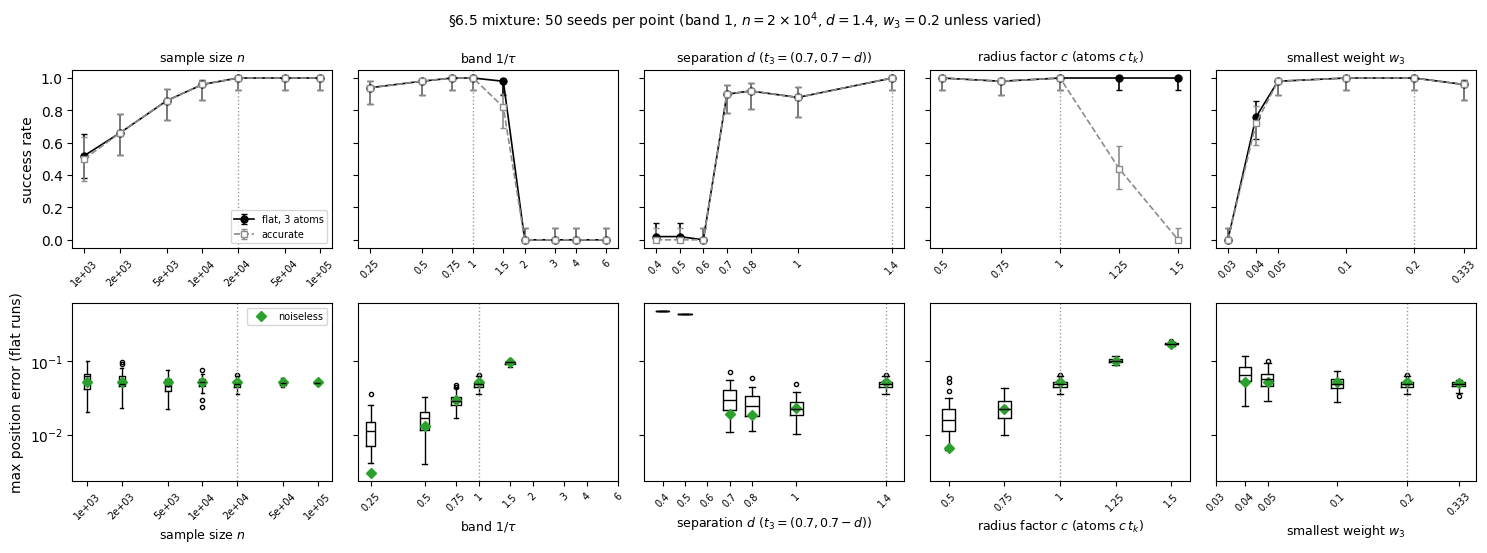

saved figs/extra/r_full_gmm_central.pdf


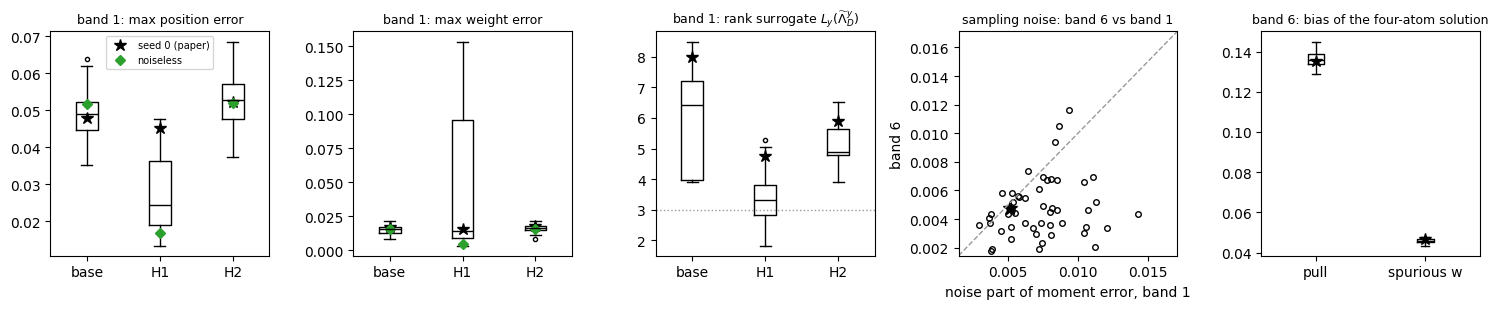

In [9]:
def rate_curve(ax, xs, runs, key_ok, **kw):
    ps = [wilson(sum(key_ok(r) for r in rs), len(rs)) for rs in runs]
    p = np.array([x[0] for x in ps]); lo = np.array([x[1] for x in ps]); hi = np.array([x[2] for x in ps])
    ax.errorbar(xs, p, yerr=[p-lo, hi-p], capsize=2.5, lw=1.2, ms=5, **kw)

fig, axs = plt.subplots(2, 5, figsize=(15, 5.6), sharey="row")
for j, (name, sw) in enumerate(GSWEEPS.items()):
    xs = np.array(sw["vals"], float); runs = gres[name]["runs"]; nl = gres[name]["noiseless"]
    ax = axs[0, j]
    rate_curve(ax, xs, runs, lambda r: r["flat"], fmt="o-", color="k", label="flat, 3 atoms")
    rate_curve(ax, xs, runs, lambda r: r["flat"] and r.get("dpos",9) <= 0.1 and r.get("dw",9) <= 0.05,
               fmt="s--", color="0.55", mfc="white", label="accurate")
    ax.axvline(sw["paper"], color="0.6", ls=":", lw=1)
    ax.set_ylim(-0.05, 1.05); ax.set_title(sw["label"], fontsize=9)
    if sw["log"]: ax.set_xscale("log")
    ax.set_xticks(xs); ax.set_xticklabels([f"{v:.3g}" for v in xs], fontsize=7, rotation=45); ax.minorticks_off()
    ax = axs[1, j]
    data = [[r["dpos"] for r in rs if r["flat"] and r.get("dpos") is not None] for rs in runs]
    wdt = (0.12*xs) if sw["log"] else 0.06*(xs.max()-xs.min())*np.ones_like(xs)
    keep = [i for i, dd in enumerate(data) if len(dd)]
    ax.boxplot([data[i] for i in keep], positions=xs[keep], widths=wdt[keep], manage_ticks=False,
               flierprops=dict(ms=3), medianprops=dict(color="k"))
    ynl = [r.get("dpos", np.nan) if r["flat"] else np.nan for r in nl]
    ax.plot(xs, ynl, "D", color="C2", ms=5, label="noiseless")
    ax.axvline(sw["paper"], color="0.6", ls=":", lw=1)
    ax.set_yscale("log"); ax.set_xlabel(sw["label"], fontsize=9)
    if sw["log"]: ax.set_xscale("log")
    ax.set_xticks(xs); ax.set_xticklabels([f"{v:.3g}" for v in xs], fontsize=7, rotation=45); ax.minorticks_off()
axs[0, 0].set_ylabel("success rate"); axs[1, 0].set_ylabel("max position error (flat runs)")
axs[0, 0].legend(fontsize=7, loc="lower right"); axs[1, 0].legend(fontsize=7)
fig.suptitle(f"§4.4 mixture: {GMM_SEEDS} seeds per point (band 1, $n=2\\times10^4$, $d=1.4$, $w_3=0.2$ unless varied)", fontsize=10)
fig.tight_layout(); savefig(fig, "r_gmm_sweeps"); plt.show()

fig, axs = plt.subplots(1, 5, figsize=(15, 3.2))
def box_with_star(ax, data, stars, labels, paper=None):
    ax.boxplot(data, tick_labels=labels, flierprops=dict(ms=3), medianprops=dict(color="k"))
    ax.plot(range(1, len(stars)+1), stars, "*", color="k", ms=9, label="seed 0 (paper)")
    if paper is not None:
        for i, p in enumerate(paper):
            if p is not None: ax.plot([i+0.7, i+1.3], [p, p], color="0.5", ls="--", lw=1)
ok = [r for r in central]
box_with_star(axs[0], [col(ok,"dpos"), col(ok,"h1_dpos"), col(ok,"h2_dpos")],
              [r0["dpos"], r0["h1_dpos"], r0["h2_dpos"]], ["base", "H1", "H2"])
axs[0].plot([1, 2, 3], [nl1["dpos"], nl1.get("h1_dpos", np.nan), nl1.get("h2_dpos", np.nan)], "D", color="C2", ms=5, label="noiseless")
axs[0].set_title("band 1: max position error", fontsize=9); axs[0].legend(fontsize=7)
box_with_star(axs[1], [col(ok,"dw"), col(ok,"h1_dw"), col(ok,"h2_dw")],
              [r0["dw"], r0["h1_dw"], r0["h2_dw"]], ["base", "H1", "H2"])
axs[1].plot([1, 2, 3], [nl1["dw"], nl1.get("h1_dw", np.nan), nl1.get("h2_dw", np.nan)], "D", color="C2", ms=5)
axs[1].set_title("band 1: max weight error", fontsize=9)
box_with_star(axs[2], [col(ok,"L"), col(ok,"h1_L"), col(ok,"h2_L")], [r0["L"], r0["h1_L"], r0["h2_L"]],
              ["base", "H1", "H2"])
axs[2].axhline(3, color="0.6", ls=":", lw=1); axs[2].set_title("band 1: rank surrogate $L_y(\\widetilde\\Lambda^y_D)$", fontsize=9)
xb = np.array(col(central, "mom_noise")); xw = np.array(col(broad, "mom_noise"))
axs[3].plot(xb, xw, "o", color="k", ms=4, mfc="none"); axs[3].plot(xb[:1], xw[:1], "*", color="k", ms=10)
lim = [0.8*min(xb.min(), xw.min()), 1.2*max(xb.max(), xw.max())]
axs[3].plot(lim, lim, color="0.6", ls="--", lw=1); axs[3].set_xlim(lim); axs[3].set_ylim(lim)
axs[3].set_xlabel("noise part of moment error, band 1"); axs[3].set_ylabel("band 6")
axs[3].set_title("sampling noise: band 6 vs band 1", fontsize=9)
box_with_star(axs[4], [pulls, [s_[1] for s_ in sp]], [np.mean(r6["d_each"]), r6["spurious"][0][1]],
              ["pull", "spurious w"])
axs[4].set_title("band 6: bias of the four-atom solution", fontsize=9)
fig.tight_layout(); savefig(fig, "r_gmm_central"); plt.show()

## 6. §4.5 pipeline (copied from `fig_deconv_2d.ipynb`)

Same forward model (Gaussian blur $\sigma=0.1$ sampled on the grid of $[-1.2,1.2]^2$, noise standard
deviation $\mathrm{rms}(y)/10^{\mathrm{SNR}/20}$ per sample), same raw-moment deconvolution, same signed SDP
($D=8$, $D_{\mathrm{data}}=6$, $\beta=10^{-3}$, Clarabel then SCS if Clarabel raises or returns no value), same
extraction (tolerance $3\times10^{-2}$, amplitudes $>10^{-2}\max$ kept) and same H1 loop on both blocks
($\varepsilon=0.25$, $\rho_C=10^{-3}$, six re-solves, no safeguard).

In [10]:
DCFG0 = dict(ATOMS=np.array([[-0.6,-0.6],[0.6,0.6],[0.6,-0.6]]), AMPS=np.array([1.0,0.7,-0.8]),
             SIGMA=0.1, BOX=1.2, GRID=65, D_ORDER=8, D_DATA=6, RANK_TOL=3e-2, BETA=1e-3,
             EPS_CDK=0.25, BETA_CDK=1e-3, N_CDK=6)

class Deconv:
    def __init__(self, **kw):
        c = dict(DCFG0); c.update(kw); self.c = c
        self.MONOS, self.IDX = monomials_upto(2*c["D_ORDER"])
        gx = np.linspace(-c["BOX"], c["BOX"], c["GRID"]); SX, SY = np.meshgrid(gx, gx)
        self.S = np.column_stack([SX.ravel(), SY.ravel()]); self.dx = gx[1] - gx[0]
        self.bD, _ = monomials_upto(c["D_ORDER"]); self.bL, _ = monomials_upto(c["D_ORDER"]-1)
        self.fc = [self.IDX[e] for e in self.MONOS if e[0]+e[1] <= c["D_DATA"]]
        s2 = 2*c["SIGMA"]**2
        self.w = np.array([1.0/(math.factorial(e[0])*math.factorial(e[1])*s2**(e[0]+e[1]))
                           for e in (self.MONOS[k] for k in self.fc)])
        b2 = c["BOX"]**2
        self.Tm  = self.sel_loc(self.bD, [(1.0,(0,0))])
        self.Tl1 = self.sel_loc(self.bL, [(b2,(0,0)),(-1,(2,0))]); self.Tl2 = self.sel_loc(self.bL, [(b2,(0,0)),(-1,(0,2))])
        y = np.zeros(len(self.S))
        for a, t in zip(c["AMPS"], c["ATOMS"]):
            y += a*np.exp(-np.sum((self.S-t)**2, axis=1)/(2*c["SIGMA"]**2))/(2*np.pi*c["SIGMA"]**2)
        self.y = y; self.rms = np.sqrt(np.mean(y**2))
        cols = [e for e in self.MONOS if e[0]+e[1] <= c["D_DATA"]]; self.cols = cols; sig = c["SIGMA"]
        def muZ(k): return (0.0 if k % 2 else float(math.prod(range(1, k, 2)))*sig**k) if k > 0 else 1.0
        n = len(cols); L = np.zeros((n, n))
        for ia, a in enumerate(cols):
            for ib, b in enumerate(cols):
                if b[0] <= a[0] and b[1] <= a[1]:
                    L[ia, ib] = math.comb(a[0], b[0])*math.comb(a[1], b[1])*muZ(a[0]-b[0])*muZ(a[1]-b[1])
        self.L = L; self.Smon = np.array([self.S[:,0]**e[0]*self.S[:,1]**e[1] for e in cols])
        self.log = []

    sel_loc = GMM.sel_loc
    _rref_pivots = staticmethod(GMM._rref_pivots)
    christoffel_weight = staticmethod(GMM.christoffel_weight)

    def draw(self, snr, rng_seed):                   # noisy grid samples; snr=None: noiseless
        if snr is None: return self.y.copy()
        e = self.rms/(10**(snr/20)); return self.y + e*np.random.default_rng(rng_seed).standard_normal(len(self.S))

    def raw_deconv_moments(self, yv):
        mm = np.linalg.solve(self.L, (self.dx**2)*(self.Smon @ yv)); m = np.zeros(len(self.MONOS))
        for cc, e in zip(mm, self.cols): m[self.IDX[e]] = cc
        return m

    def mtrue(self):
        c = self.c
        return np.array([np.sum(c["AMPS"]*c["ATOMS"][:,0]**e[0]*c["ATOMS"][:,1]**e[1]) for e in self.MONOS])

    def solve(self, mh, cdkp=None, cdkm=None, tag=""):
        c = self.c; nD, nL = len(self.bD), len(self.bL); fc = self.fc
        yp = cp.Variable(len(self.MONOS)); ym = cp.Variable(len(self.MONOS)); df = yp - ym
        Mp = cp.reshape(self.Tm@yp, (nD,nD), order="C"); Mm = cp.reshape(self.Tm@ym, (nD,nD), order="C")
        cons = [Mp >> 0, Mm >> 0,
                cp.reshape(self.Tl1@yp,(nL,nL),order="C") >> 0, cp.reshape(self.Tl2@yp,(nL,nL),order="C") >> 0,
                cp.reshape(self.Tl1@ym,(nL,nL),order="C") >> 0, cp.reshape(self.Tl2@ym,(nL,nL),order="C") >> 0]
        if cdkp is not None: cons.append(cp.sum(cp.multiply(cdkp[0], Mp)) <= cdkp[1])   # H1 on y_+
        if cdkm is not None: cons.append(cp.sum(cp.multiply(cdkm[0], Mm)) <= cdkm[1])   # H1 on y_-
        obj = 0.5*cp.sum(cp.multiply(self.w, cp.square(df[fc] - mh[fc]))) + c["BETA"]*(yp[0] + ym[0])
        prob = cp.Problem(cp.Minimize(obj), cons); solver, status, msg = "CLARABEL", None, ""
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                prob.solve(solver=cp.CLARABEL, time_limit=180.0)
            status = prob.status
            if yp.value is None: raise RuntimeError("no value")
        except Exception as e:
            solver, msg = "SCS", f"CLARABEL: {type(e).__name__}"
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    prob.solve(solver=cp.SCS, max_iters=30000)
                status = prob.status
            except Exception as e2:
                self.log.append((tag, "SCS", "failed", msg + f"; SCS: {type(e2).__name__}")); return None, None
        self.log.append((tag, solver, status, msg))
        return yp.value, ym.value

    def mm(self, yv):
        nb = len(self.bD); M = np.empty((nb, nb)); I = self.IDX
        for a, ea in enumerate(self.bD):
            for b, eb in enumerate(self.bD):
                M[a, b] = yv[I[(ea[0]+eb[0], ea[1]+eb[1])]]
        return M

    def extract(self, M):
        bD = self.bD; tol = self.c["RANK_TOL"]; D = self.c["D_ORDER"]
        pos = {e: i for i, e in enumerate(bD)}; deg = [e[0]+e[1] for e in bD]
        s = np.linalg.svd(M, compute_uv=False); rank = int(np.sum(s > tol*s[0]))
        if rank < 1: return np.zeros((0, 2)), np.zeros(0)
        piv = [p for p in self._rref_pivots(M, tol*s[0]) if deg[p] <= D-1]; piv = sorted(piv, key=lambda i: (deg[i], i))
        if len(piv) < rank: raise RuntimeError(f"not flat: rank {rank}, {len(piv)} low-deg pivots")
        pv = piv[:rank]; B = [bD[i] for i in pv]; Mpp = M[np.ix_(pv, pv)]; mult = []
        for k in range(2):
            Nk = np.zeros((rank, rank))
            for j, be in enumerate(B):
                sh = (be[0]+(1 if k == 0 else 0), be[1]+(1 if k == 1 else 0)); si = pos.get(sh)
                if si is None: raise RuntimeError("shift outside basis")
                Nk[:, j] = np.linalg.solve(Mpp, np.array([M[pv[i], si] for i in range(rank)]))
            mult.append(Nk)
        g = np.random.default_rng(1).standard_normal(2); _, V = np.linalg.eig(g[0]*mult[0] + g[1]*mult[1]); Vi = np.linalg.inv(V)
        coords = np.column_stack([np.real(np.diag(Vi@mult[k]@V)) for k in range(2)])
        Phi = np.array([[a[0]**e[0]*a[1]**e[1] for a in coords] for e in B], float)
        wt, *_ = np.linalg.lstsq(Phi, np.array([M[pv[i], pos[(0,0)]] for i in range(rank)]), rcond=None)
        return coords, wt

    def recover(self, yp, ym):                        # extraction from y_+ and y_- (sweep cell 22)
        out = {}
        for yy, sgn, lab in [(yp, 1, "+"), (ym, -1, "-")]:
            M = self.mm(yy); sv = np.linalg.svd(M, compute_uv=False); out["sv"+lab] = (sv/sv[0])[:8].tolist()
            out["rank"+lab] = int(np.sum(sv > self.c["RANK_TOL"]*sv[0]))
            try:
                a, wt = self.extract(M); k = np.abs(wt) > 1e-2*max(np.max(np.abs(wt)) if len(wt) else 1, 1e-12)
                out["atoms"+lab] = a[k]; out["amps"+lab] = sgn*wt[k]; out["err"+lab] = None
            except Exception as ex:
                out["atoms"+lab] = None; out["amps"+lab] = None; out["err"+lab] = str(ex)
        return out

    def eta(self, mh, yp, ym, P):
        diff = yp - ym; out = np.zeros(len(P))
        for k, wk in zip(self.fc, self.w):
            e = self.MONOS[k]; out += wk*(mh[k] - diff[k])/self.c["BETA"]*P[:,0]**e[0]*P[:,1]**e[1]
        return out

def match_signed(ATOMS, AMPS, rec):
    # positive true spikes -> y_+ atoms, negative -> y_- atoms; None if a block has too few atoms
    dps, das = [], []
    for lab, mask in [("+", AMPS > 0), ("-", AMPS < 0)]:
        ta, tw = ATOMS[mask], AMPS[mask]
        if len(ta) == 0: continue
        m = match(ta, tw, rec["atoms"+lab], rec["amps"+lab])
        if m is None: return None
        dps += list(m["d"]); das += list(m["dws"])
    return float(max(dps)), float(max(das))

def dec_summary(Dc, mh, yp, ym, cert=False):
    c = Dc.c; npos, nneg = int(np.sum(c["AMPS"] > 0)), int(np.sum(c["AMPS"] < 0))
    rec = Dc.recover(yp, ym); fc = Dc.fc
    out = {k: rec[k] for k in ("sv+", "sv-", "rank+", "rank-", "err+", "err-")}
    out["n+"] = None if rec["atoms+"] is None else len(rec["atoms+"])
    out["n-"] = None if rec["atoms-"] is None else len(rec["atoms-"])
    out["ok+"] = out["n+"] == npos; out["ok-"] = out["n-"] == nneg; out["success"] = out["ok+"] and out["ok-"]
    out["crit+"] = rec["sv+"][npos] if npos < 8 else np.nan      # first singular value that must vanish
    out["crit-"] = rec["sv-"][nneg] if nneg < 8 else np.nan
    out["gap+"] = rec["sv+"][npos-1]/rec["sv+"][npos] if npos else np.nan
    out["gap-"] = rec["sv-"][nneg-1]/rec["sv-"][nneg] if nneg else np.nan
    out["mom_err"] = float(np.max(np.abs(mh[fc] - Dc.mtrue()[fc])))
    m = match_signed(c["ATOMS"], c["AMPS"], rec) if out["success"] else None
    out["dpos"], out["da"] = (m if m is not None else (np.nan, np.nan))
    out["accurate"] = bool(out["success"] and out["dpos"] <= 0.05 and out["da"] <= 0.1)
    if cert:
        g = np.linspace(-c["BOX"], c["BOX"], 161); XX, YY = np.meshgrid(g, g); P = np.column_stack([XX.ravel(), YY.ravel()])
        e = Dc.eta(mh, yp, ym, P); away = np.min(np.linalg.norm(P[:,None,:] - c["ATOMS"][None], axis=2), axis=1) > 0.15
        out["eta_max"] = float(np.abs(e).max()); out["eta_spikes"] = Dc.eta(mh, yp, ym, c["ATOMS"]).tolist()
        i = int(np.argmax(np.abs(e)*away)); out["eta_away"] = float(np.abs(e[i])); out["eta_away_at"] = P[i].tolist()
    return out

def dec_task(over, snr, rng_seed, cert=False):
    Dc = Deconv(**over); t0 = time.time()
    mh = Dc.raw_deconv_moments(Dc.draw(snr, rng_seed)); yp, ym = Dc.solve(mh, tag="base")
    if yp is None:                                   # no solution: record a failed case with empty diagnostics
        nan8 = [np.nan]*8
        return {"snr": snr, "rng_seed": rng_seed, "success": False, "accurate": False, "ok+": False, "ok-": False,
                "sv+": nan8, "sv-": nan8, "rank+": -1, "rank-": -1, "err+": "no solution", "err-": "no solution",
                "n+": None, "n-": None, "crit+": np.nan, "crit-": np.nan, "gap+": np.nan, "gap-": np.nan,
                "dpos": np.nan, "da": np.nan, "mom_err": np.nan, "eta_max": np.nan, "eta_away": np.nan,
                "eta_away_at": [np.nan, np.nan], "eta_spikes": [], "log": Dc.log, "time": time.time()-t0}
    out = dec_summary(Dc, mh, yp, ym, cert=cert)
    out.update(snr=snr, rng_seed=rng_seed, log=Dc.log, time=time.time()-t0)
    return out

def dec_h1_task(over, snr, rng_seed):
    # base solve, then six H1 re-solves on both blocks exactly as cell 19 of the paper notebook
    Dc = Deconv(**over); c = Dc.c; t0 = time.time()
    mh = Dc.raw_deconv_moments(Dc.draw(snr, rng_seed)); ypb, ymb = Dc.solve(mh, tag="base")
    if ypb is None: raise RuntimeError(f"base solve failed at {snr} dB, rng({rng_seed}): {Dc.log}")
    base = dec_summary(Dc, mh, ypb, ymb); yps, yms = ypb.copy(), ymb.copy(); n_it = 0
    for it in range(c["N_CDK"]):
        Wp, Lp = Dc.christoffel_weight(Dc.mm(yps), c["BETA_CDK"]); Wm, Lm = Dc.christoffel_weight(Dc.mm(yms), c["BETA_CDK"])
        o = Dc.solve(mh, cdkp=(Wp, (1-c["EPS_CDK"])*Lp), cdkm=(Wm, (1-c["EPS_CDK"])*Lm), tag=f"H1.{it}")
        if o[0] is None: break
        yps, yms = o; n_it += 1
    h1 = dec_summary(Dc, mh, yps, yms)
    return dict(snr=snr, rng_seed=rng_seed, base=base, h1=h1, n_it=n_it, log=Dc.log, time=time.time()-t0)

**Reproduction check.** The paper's $40$ dB draw (`default_rng(0)`) must give ranks $2$ / $1$, singular values
$1, 0.564, 0.021$ ($y_+$) and $1, 0.0256$ ($y_-$), and errors $2.2\times10^{-3}$ / $1.4\times10^{-3}$; the certificate
$\max|\eta|=1.00001$ with $0.99992$ at the corner $(1.2,1.2)$.

In [11]:
p40 = dec_task({}, 40, 0, cert=True)
print(f"paper draw 40 dB: ranks {p40['rank+']}/{p40['rank-']}, sv+ {np.round(p40['sv+'][:4],4)}, sv- {np.round(p40['sv-'][:3],4)}, "
      f"gaps {p40['gap+']:.1f} / {p40['gap-']:.1f}, dpos {p40['dpos']:.2e}, da {p40['da']:.2e}")
print(f"   certificate max|eta| {p40['eta_max']:.5f}, eta at spikes {np.round(p40['eta_spikes'],5)}, "
      f"max|eta| away from spikes {p40['eta_away']:.5f} at {np.round(p40['eta_away_at'],3)}; solver {status_counts(p40['log'])}")
assert p40["success"] and abs(p40["sv+"][2]-0.021) < 1e-3 and abs(p40["sv-"][1]-0.0256) < 1e-3

paper draw 40 dB: ranks 2/1, sv+ [1.     0.5643 0.021  0.0082], sv- [1.     0.0256 0.0118], gaps 26.8 / 39.1, dpos 2.21e-03, da 1.38e-03
   certificate max|eta| 1.00001, eta at spikes [ 1.       1.      -1.00001], max|eta| away from spikes 0.99988 at [1.2 1.2]; solver {'CLARABEL:optimal_inaccurate': 1}


## 7. §4.5 noise sweep

`DEC_SEEDS` noise draws per SNR, the paper's six SNR values plus $42$ and $38$ dB, and the noiseless case.
The paper's counts (Remark `rem:signed-noise`: $6/7$ at $40$, $2/3$ at $37$, $1/5$ at $35$, $0/7$ at $32$ and
$30$ dB; $3/3$ at $45$ dB in the notebook) are shown for comparison. At $40$ dB we also record the quantities
quoted in the text (errors, singular-value gaps, certificate).

In [12]:
SNRS = [45, 42, 40, 38, 37, 35, 32, 30]
PAPER_COUNTS = {45: (3, 3), 40: (6, 7), 37: (2, 3), 35: (1, 5), 32: (0, 3), 30: (0, 4)}  # 30 dB: 3 sweep + rescue base draw
PAPER_COUNTS_TEXT = {40: (6, 7), 37: (2, 3), 35: (1, 5), 32: (0, 7)}                     # 32 and 30 dB pooled in the text
PAPER_CASES = {45: [0, 1, 2], 40: [1, 2, 3, 4, 5, 6], 37: [0, 1, 2], 35: [0, 1, 2, 3, 4], 32: [0, 1, 2], 30: [1, 2, 3]}
args = [({}, snr, 100+s, snr == 40) for snr in SNRS for s in range(DEC_SEEDS)]
dout, tw = pmap(dec_task, args)
dsnr = {snr: dout[i*DEC_SEEDS:(i+1)*DEC_SEEDS] for i, snr in enumerate(SNRS)}
dnl = dec_task({}, None, 0, cert=True)
print(f"{len(args)} solves in {tw:.0f} s; noiseless: success {dnl['success']}, sv+ {np.round(dnl['sv+'][:4],4)}, sv- {np.round(dnl['sv-'][:3],4)}")
for snr in SNRS:
    rs = dsnr[snr]; k = sum(r["success"] for r in rs); p, lo, hi = wilson(k, len(rs))
    ka = sum(r["accurate"] for r in rs)
    fails = [r for r in rs if not r["success"]]
    both = sum((not r["ok+"]) and (not r["ok-"]) for r in fails); only_p = sum((not r["ok+"]) and r["ok-"] for r in fails)
    only_m = sum(r["ok+"] and (not r["ok-"]) for r in fails)
    pc = PAPER_COUNTS.get(snr)
    pcs = [rs[s_] for s_ in PAPER_CASES.get(snr, []) if s_ < len(rs)]
    print(f"{snr} dB: success {k}/{len(rs)} = {p:.2f} [{lo:.2f}, {hi:.2f}] | accurate {ka} | failures: y+ only {only_p}, y- only {only_m}, both {both}"
          f" | med crit s.v. y+ {np.median([r['crit+'] for r in rs]):.4f}, y- {np.median([r['crit-'] for r in rs]):.4f}"
          + (f" | paper {pc[0]}/{pc[1]}, its sweep seeds here {sum(r['success'] for r in pcs)}/{len(pcs)}" if pc else ""))
print("solver statuses:", status_counts([l for r in dout for l in r["log"]]))
tol = DCFG0["RANK_TOL"]
mism = [(r["snr"], r["rng_seed"]) for r in dout if r["success"] != (r["crit+"] < tol and r["crit-"] < tol)]
nf = sum(not r["success"] for r in dout)
print(f"failure <=> (s3/s1 of y+ or s2/s1 of y- above the tolerance): {len(mism)} exceptions {mism} among {len(dout)} draws; "
      f"of the {nf} failures, y- crosses in {sum((not r['success']) and r['crit-'] >= tol for r in dout)}, y+ in {sum((not r['success']) and r['crit+'] >= tol for r in dout)}")

r40 = dsnr[40]; s40 = [r for r in r40 if r["success"]]
print(f"\n--- 40 dB, {len(r40)} draws (paper, one draw: dpos 2.2e-3, da 1.4e-3, gaps 27 / 39, max|eta| 1.00001, corner 0.99992) ---")
print("max position error (successes):", q([r["dpos"] for r in s40]))
print("max amplitude error (successes):", q([r["da"] for r in s40]))
print("gap y+ (s2/s3)                :", q([r["gap+"] for r in r40]))
print("gap y- (s1/s2)                :", q([r["gap-"] for r in r40]))
print("moment error                  :", q([r["mom_err"] for r in r40]))
print("max|eta| on X                 :", q([r["eta_max"] for r in r40], fmt="{:.5f}"))
print("max|eta| at distance > 0.15   :", q([r["eta_away"] for r in r40], fmt="{:.5f}"))
for st_ in ("optimal", "optimal_inaccurate"):
    sel = [r["eta_max"] for r in r40 if r["log"][0][2] == st_]
    print(f"max|eta| when Clarabel returns {st_:18s}:", q(sel, fmt="{:.5f}"))
print(f"max|eta| > 1.001 in {sum(r['eta_max'] > 1.001 for r in r40)}/{len(r40)} draws, > 1.5 in {sum(r['eta_max'] > 1.5 for r in r40)}; "
      f"max |eta(t_k) - sign(a_k)| {q([max(abs(v - np.sign(a)) for v, a in zip(r['eta_spikes'], DCFG0['AMPS'])) for r in r40])}")
corner = sum(max(abs(r["eta_away_at"][0]), abs(r["eta_away_at"][1])) > 1.19 for r in r40)
print(f"that maximum sits on the boundary of X in {corner}/{len(r40)} draws; locations:",
      sorted(set(tuple(np.round(r['eta_away_at'], 2)) for r in r40)))

400 solves in 380 s; noiseless: success True, sv+ [1.000e+00 5.615e-01 1.000e-04 1.000e-04], sv- [1.e+00 2.e-04 1.e-04]
45 dB: success 49/50 = 0.98 [0.90, 1.00] | accurate 49 | failures: y+ only 0, y- only 1, both 0 | med crit s.v. y+ 0.0084, y- 0.0110 | paper 3/3, its sweep seeds here 3/3
42 dB: success 46/50 = 0.92 [0.81, 0.97] | accurate 46 | failures: y+ only 1, y- only 3, both 0 | med crit s.v. y+ 0.0118, y- 0.0154
40 dB: success 41/50 = 0.82 [0.69, 0.90] | accurate 41 | failures: y+ only 4, y- only 5, both 0 | med crit s.v. y+ 0.0148, y- 0.0193 | paper 6/7, its sweep seeds here 5/6
38 dB: success 31/50 = 0.62 [0.48, 0.74] | accurate 31 | failures: y+ only 4, y- only 13, both 2 | med crit s.v. y+ 0.0186, y- 0.0244
37 dB: success 25/50 = 0.50 [0.37, 0.63] | accurate 25 | failures: y+ only 6, y- only 14, both 5 | med crit s.v. y+ 0.0208, y- 0.0274 | paper 2/3, its sweep seeds here 2/3
35 dB: success 13/50 = 0.26 [0.16, 0.40] | accurate 13 | failures: y+ only 5, y- only 20, both 12 |

## 8. §4.5 sweeps at fixed SNR

* separation $d$ of the opposite-sign pair: the negative spike moves from $(0.6,-0.6)$ towards $(0.6,0.6)$,
  $t_3=(0.6,0.6-d)$; $d=1.2$ is the paper's configuration ($40$ dB);
* number of spikes $s=2,\dots,6$ on the circle of radius $0.6\sqrt2$ through the paper's spikes, equally spaced
  from the angle $225^\circ$, amplitudes $(1,-0.8,0.7,-0.9,0.6,-0.75)$ truncated to $s$ (minimum separation
  $1.70, 1.47, 1.20, 1.00, 0.85$); $s=3$ is not the paper's layout ($40$ dB);
* grid size at $37$ dB, near the transition: at fixed per-sample SNR a finer grid lowers the noise of the
  moment estimates (their standard deviation scales like the grid step);
* the degree of the moment fit, $D_{\mathrm{data}}=4$ against $6$ ($40$ dB), for the claim that degree-$4$
  moments do not resolve the signed split.

In [13]:
def atoms_dd(d): A = DCFG0["ATOMS"].copy(); A[2] = [0.6, 0.6-d]; return A
def circle(s):
    th = np.deg2rad(225) + 2*np.pi*np.arange(s)/s
    return dict(ATOMS=0.6*np.sqrt(2)*np.column_stack([np.cos(th), np.sin(th)]),
                AMPS=np.array([1.0, -0.8, 0.7, -0.9, 0.6, -0.75])[:s])
DSWEEPS = {
    "sep":   dict(vals=[0.3, 0.45, 0.6, 0.8, 1.0, 1.2], over=lambda v: {"ATOMS": atoms_dd(v)}, snr=40,
                  label="separation $d$ of the $\\pm$ pair", paper=1.2),
    "spikes": dict(vals=[2, 3, 4, 5, 6], over=lambda v: circle(v), snr=40, label="number of spikes $s$", paper=None),
    "grid":  dict(vals=[33, 49, 65, 97, 129], over=lambda v: {"GRID": v}, snr=37, label="grid size (37 dB)", paper=65),
    "ddata": dict(vals=[4, 6], over=lambda v: {"D_DATA": v}, snr=40, label="$D_{\\mathrm{data}}$", paper=6),
}
dres = {}
for name, sw in DSWEEPS.items():
    args = [(sw["over"](v), sw["snr"], 100+s) for v in sw["vals"] for s in range(DEC_SEEDS_S)]
    out, tw = pmap(dec_task, args)
    nl, _ = pmap(dec_task, [(sw["over"](v), None, 0) for v in sw["vals"]])
    dres[name] = dict(runs=[out[i*DEC_SEEDS_S:(i+1)*DEC_SEEDS_S] for i in range(len(sw["vals"]))], noiseless=nl)
    print(f"\n=== sweep {name} at {sw['snr']} dB ({len(args)} solves, {tw:.0f} s) ===")
    for v, rs, r_nl in zip(sw["vals"], dres[name]["runs"], nl):
        k = sum(r["success"] for r in rs); p, lo, hi = wilson(k, len(rs))
        print(f"{name}={v:<5} success {k}/{len(rs)} [{lo:.2f}, {hi:.2f}] | accurate {sum(r['accurate'] for r in rs)}"
              f" | y+ fails {sum(not r['ok+'] for r in rs)}, y- fails {sum(not r['ok-'] for r in rs)}"
              f" | med crit s.v. {np.median([r['crit+'] for r in rs]):.4f} / {np.median([r['crit-'] for r in rs]):.4f}"
              f" | med dpos {np.nanmedian([r['dpos'] for r in rs]) if k else np.nan:.4f}"
              f" || noiseless: success {r_nl['success']} (ranks {r_nl['rank+']}/{r_nl['rank-']}, crit {r_nl['crit+']:.4f} / {r_nl['crit-']:.4f}"
              f", err {r_nl['err+']} / {r_nl['err-']})")
    print("solver statuses:", status_counts([l for rs in dres[name]["runs"] for r in rs for l in r["log"]]))


=== sweep sep at 40 dB (120 solves, 161 s) ===
sep=0.3   success 0/20 [0.00, 0.16] | accurate 0 | y+ fails 20, y- fails 20 | med crit s.v. 0.2330 / 0.5404 | med dpos nan || noiseless: success False (ranks 5/4, crit 0.2336 / 0.5688, err not flat: rank 5, 3 low-deg pivots / not flat: rank 4, 3 low-deg pivots)
sep=0.45  success 0/20 [0.00, 0.16] | accurate 0 | y+ fails 20, y- fails 20 | med crit s.v. 0.2772 / 0.3344 | med dpos nan || noiseless: success False (ranks 5/4, crit 0.2786 / 0.3377, err not flat: rank 5, 3 low-deg pivots / not flat: rank 4, 3 low-deg pivots)
sep=0.6   success 4/20 [0.08, 0.42] | accurate 4 | y+ fails 4, y- fails 16 | med crit s.v. 0.0232 / 0.0378 | med dpos 0.0023 || noiseless: success True (ranks 2/1, crit 0.0063 / 0.0112, err None / None)
sep=0.8   success 7/20 [0.18, 0.57] | accurate 7 | y+ fails 3, y- fails 12 | med crit s.v. 0.0155 / 0.0310 | med dpos 0.0018 || noiseless: success True (ranks 2/1, crit 0.0003 / 0.0012, err None / None)
sep=1.0   success 12/2


=== sweep spikes at 40 dB (100 solves, 114 s) ===
spikes=2     success 18/20 [0.70, 0.97] | accurate 18 | y+ fails 2, y- fails 0 | med crit s.v. 0.0136 / 0.0130 | med dpos 0.0016 || noiseless: success True (ranks 1/1, crit 0.0002 / 0.0002, err None / None)
spikes=3     success 19/20 [0.76, 0.99] | accurate 19 | y+ fails 1, y- fails 0 | med crit s.v. 0.0141 / 0.0114 | med dpos 0.0012 || noiseless: success True (ranks 2/1, crit 0.0006 / 0.0006, err None / None)
spikes=4     success 17/20 [0.64, 0.95] | accurate 17 | y+ fails 2, y- fails 1 | med crit s.v. 0.0177 / 0.0165 | med dpos 0.0014 || noiseless: success True (ranks 2/2, crit 0.0000 / 0.0000, err None / None)
spikes=5     success 15/20 [0.53, 0.89] | accurate 15 | y+ fails 3, y- fails 2 | med crit s.v. 0.0181 / 0.0208 | med dpos 0.0018 || noiseless: success True (ranks 3/2, crit 0.0022 / 0.0020, err None / None)
spikes=6     success 0/20 [0.00, 0.16] | accurate 0 | y+ fails 20, y- fails 20 | med crit s.v. 0.1879 / 0.2297 | med dpos


=== sweep grid at 37 dB (100 solves, 105 s) ===
grid=33    success 0/20 [0.00, 0.16] | accurate 0 | y+ fails 16, y- fails 19 | med crit s.v. 0.0485 / 0.0629 | med dpos nan || noiseless: success True (ranks 2/1, crit 0.0001 / 0.0002, err None / None)
grid=49    success 5/20 [0.11, 0.47] | accurate 5 | y+ fails 10, y- fails 13 | med crit s.v. 0.0298 / 0.0433 | med dpos 0.0049 || noiseless: success True (ranks 2/1, crit 0.0001 / 0.0002, err None / None)
grid=65    success 9/20 [0.26, 0.66] | accurate 9 | y+ fails 3, y- fails 8 | med crit s.v. 0.0206 / 0.0267 | med dpos 0.0021 || noiseless: success True (ranks 2/1, crit 0.0001 / 0.0002, err None / None)
grid=97    success 16/20 [0.58, 0.92] | accurate 16 | y+ fails 1, y- fails 3 | med crit s.v. 0.0108 / 0.0173 | med dpos 0.0022 || noiseless: success True (ranks 2/1, crit 0.0001 / 0.0002, err None / None)
grid=129   success 20/20 [0.84, 1.00] | accurate 20 | y+ fails 0, y- fails 0 | med crit s.v. 0.0105 / 0.0137 | med dpos 0.0017 || noisel


=== sweep ddata at 40 dB (40 solves, 41 s) ===
ddata=4     success 0/20 [0.00, 0.16] | accurate 0 | y+ fails 20, y- fails 20 | med crit s.v. 0.0885 / 0.4062 | med dpos nan || noiseless: success False (ranks 3/4, crit 0.0885 / 0.4059, err None / not flat: rank 4, 3 low-deg pivots)
ddata=6     success 17/20 [0.64, 0.95] | accurate 17 | y+ fails 2, y- fails 1 | med crit s.v. 0.0147 / 0.0188 | med dpos 0.0015 || noiseless: success True (ranks 2/1, crit 0.0001 / 0.0002, err None / None)
solver statuses: {'CLARABEL:optimal_inaccurate': 37, 'CLARABEL:optimal': 3}


## 9. H1 rescue over several noise draws

The paper shows one draw at $30$ dB (`default_rng(1)`). We rerun the same six-step H1 loop on that draw and
on `H1_SEEDS` sweep draws per SNR in `H1_SNRS`. Each rescue costs about two to three minutes, because
Clarabel fails on the H1 re-solves and SCS runs up to $30000$ iterations.

In [14]:
h1_args = [({}, 30, 1)] + [({}, snr, 100+s) for snr in H1_SNRS for s in range(H1_SEEDS)]
h1out, tw = pmap(dec_h1_task, h1_args)
print(f"{len(h1_args)} rescues in {tw:.0f} s")
for r in h1out:
    b, h = r["base"], r["h1"]
    tag = "paper draw rng(1)" if r["rng_seed"] == 1 else f"rng({r['rng_seed']})"
    print(f"{r['snr']} dB {tag:17s}: base ranks {b['rank+']}/{b['rank-']} success {b['success']} -> H1 ({r['n_it']} it) ranks "
          f"{h['rank+']}/{h['rank-']} success {h['success']}, dpos {h['dpos']:.1e}, da {h['da']:.1e} | {status_counts(r['log'])}"
          f" | {r['time']:.0f} s")
for snr in H1_SNRS:
    rs = [r for r in h1out if r["snr"] == snr and r["rng_seed"] != 1]
    kb = sum(r["base"]["success"] for r in rs); kh = sum(r["h1"]["success"] for r in rs); ka = sum(r["h1"]["accurate"] for r in rs)
    print(f"{snr} dB sweep draws: base success {kb}/{len(rs)}, H1 success {kh}/{len(rs)} {wilson(kh, len(rs))[1:]}, H1 accurate {ka}/{len(rs)}")

41 rescues in 1875 s
30 dB paper draw rng(1): base ranks 4/3 success False -> H1 (6 it) ranks 2/1 success True, dpos 8.6e-03, da 1.7e-02 | {'CLARABEL:optimal': 1, 'SCS:optimal': 3, 'SCS:optimal_inaccurate': 3} | 211 s
30 dB rng(100)         : base ranks 3/2 success False -> H1 (6 it) ranks 2/1 success True, dpos 5.7e-03, da 1.7e-02 | {'CLARABEL:optimal': 1, 'CLARABEL:optimal_inaccurate': 1, 'SCS:optimal': 5} | 83 s
30 dB rng(101)         : base ranks 3/3 success False -> H1 (6 it) ranks 2/1 success True, dpos 5.7e-03, da 3.5e-02 | {'CLARABEL:optimal_inaccurate': 1, 'SCS:optimal': 4, 'SCS:optimal_inaccurate': 2} | 138 s
30 dB rng(102)         : base ranks 4/2 success False -> H1 (6 it) ranks 2/1 success True, dpos 9.2e-03, da 2.5e-02 | {'CLARABEL:optimal_inaccurate': 2, 'SCS:optimal': 5} | 91 s
30 dB rng(103)         : base ranks 2/3 success False -> H1 (6 it) ranks 2/1 success True, dpos 8.3e-03, da 2.5e-02 | {'CLARABEL:optimal_inaccurate': 2, 'SCS:optimal': 3, 'SCS:optimal_inaccurate'

## 10. §4.5 figures

`r_deconv_snr.pdf`: (a) success rate against SNR with Wilson intervals (filled: this sweep; open squares:
the paper's counts; crosses: H1 rescue on the sweep draws); (b) the first singular value that must vanish,
$s_3/s_1$ of $M_D(y_+)$ (red) and $s_2/s_1$ of $M_D(y_-)$ (blue), median and interquartile range, with the
tolerance $3\times10^{-2}$; (c) max position error of the successful draws. `r_deconv_sweeps.pdf`: success
rate and critical singular values for the separation, number of spikes and grid sweeps (diamonds: noiseless).

saved figs/extra/r_full_deconv_snr.pdf


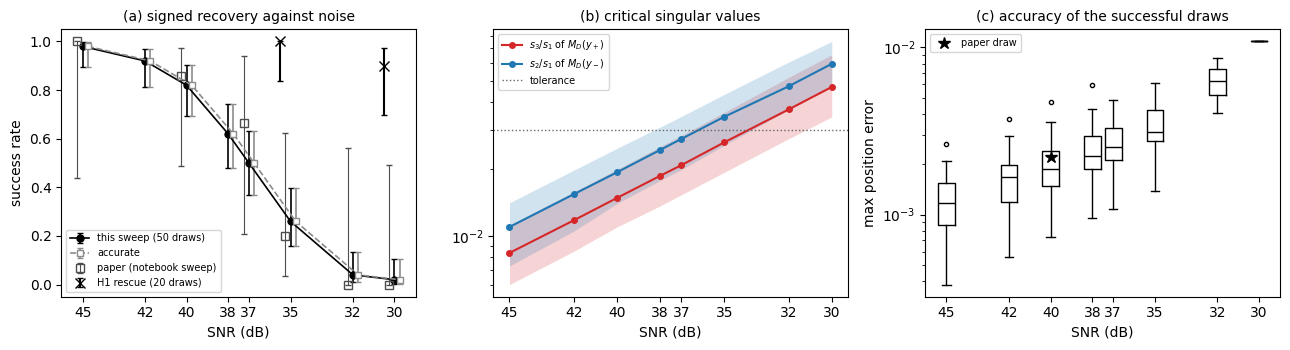

saved figs/extra/r_full_deconv_sweeps.pdf


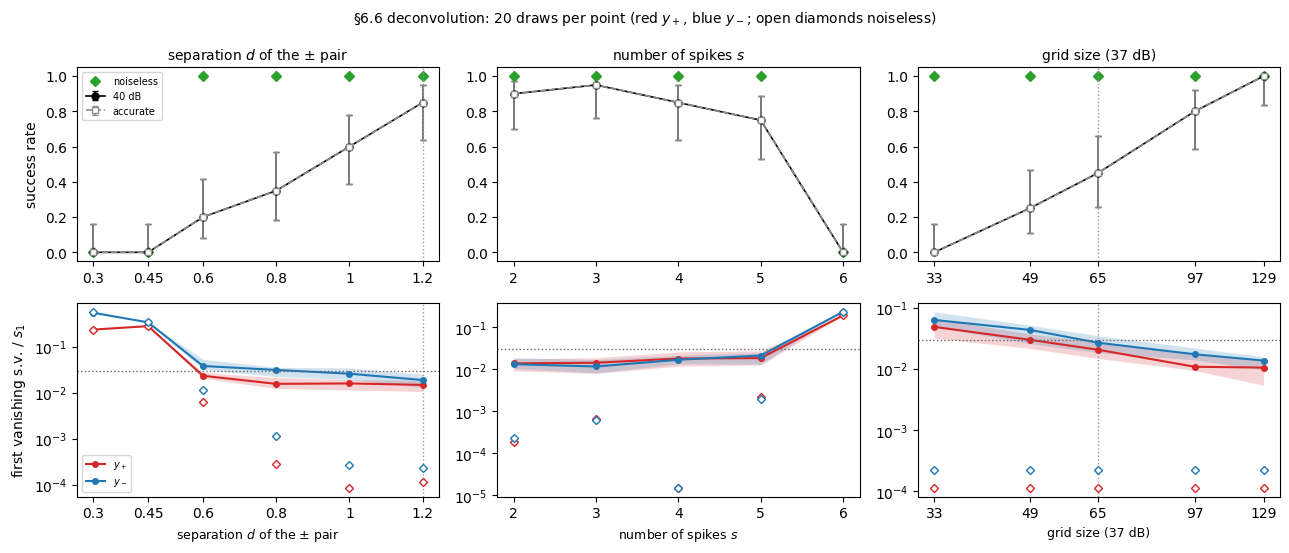

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
x = np.array(SNRS, float)
rate_curve(axs[0], x, [dsnr[s] for s in SNRS], lambda r: r["success"], fmt="o-", color="k", label=f"this sweep ({DEC_SEEDS} draws)")
rate_curve(axs[0], x - 0.25, [dsnr[s] for s in SNRS], lambda r: r["accurate"], fmt="s--", color="0.55", mfc="white", label="accurate")
xp = np.array(sorted(PAPER_COUNTS)); ps = [wilson(*PAPER_COUNTS[s]) for s in xp]
axs[0].errorbar(xp + 0.25, [p[0] for p in ps], yerr=[[p[0]-p[1] for p in ps], [p[2]-p[0] for p in ps]], fmt="s", color="0.3",
                mfc="none", capsize=2.5, lw=0.8, label="paper (notebook sweep)")
for snr in H1_SNRS:
    rs = [r for r in h1out if r["snr"] == snr and r["rng_seed"] != 1]; ph = wilson(sum(r["h1"]["success"] for r in rs), len(rs))
    axs[0].errorbar([snr + 0.5], [ph[0]], yerr=[[ph[0]-ph[1]], [ph[2]-ph[0]]], fmt="x", color="k", ms=7, capsize=2.5,
                    label=f"H1 rescue ({len(rs)} draws)" if snr == H1_SNRS[0] else None)
axs[0].set_xlabel("SNR (dB)"); axs[0].set_ylabel("success rate"); axs[0].set_ylim(-0.05, 1.05); axs[0].legend(fontsize=7, loc="lower left")
axs[0].set_title("(a) signed recovery against noise", fontsize=10)
for key, colr, lab in [("crit+", "C3", "$s_3/s_1$ of $M_D(y_+)$"), ("crit-", "C0", "$s_2/s_1$ of $M_D(y_-)$")]:
    Q = np.array([np.percentile([r[key] for r in dsnr[s]], [25, 50, 75]) for s in SNRS])
    axs[1].fill_between(x, Q[:,0], Q[:,2], color=colr, alpha=0.2, lw=0); axs[1].plot(x, Q[:,1], "o-", color=colr, ms=4, label=lab)
axs[1].axhline(DCFG0["RANK_TOL"], color="0.4", ls=":", lw=1, label="tolerance")
axs[1].set_yscale("log"); axs[1].set_xlabel("SNR (dB)"); axs[1].legend(fontsize=7); axs[1].set_title("(b) critical singular values", fontsize=10)
data = [[r["dpos"] for r in dsnr[s] if r["success"]] for s in SNRS]; keep = [i for i, d_ in enumerate(data) if d_]
axs[2].boxplot([data[i] for i in keep], positions=x[keep], widths=0.8, manage_ticks=False, flierprops=dict(ms=3), medianprops=dict(color="k"))
axs[2].plot([40], [p40["dpos"]], "*", color="k", ms=9, label="paper draw")
axs[2].set_yscale("log"); axs[2].set_xlabel("SNR (dB)"); axs[2].set_ylabel("max position error"); axs[2].legend(fontsize=7)
axs[2].set_title("(c) accuracy of the successful draws", fontsize=10); axs[2].set_xlim(46, 29)
axs[2].set_xticks(x); axs[0].set_xticks(x); axs[1].set_xticks(x)
axs[0].invert_xaxis(); axs[1].invert_xaxis()
fig.tight_layout(); savefig(fig, "r_deconv_snr"); plt.show()

names = ["sep", "spikes", "grid"]
fig, axs = plt.subplots(2, 3, figsize=(13, 5.6))
for j, name in enumerate(names):
    sw = DSWEEPS[name]; xs = np.array(sw["vals"], float); runs = dres[name]["runs"]; nl = dres[name]["noiseless"]
    rate_curve(axs[0, j], xs, runs, lambda r: r["success"], fmt="o-", color="k", label=f"{sw['snr']} dB")
    rate_curve(axs[0, j], xs, runs, lambda r: r["accurate"], fmt="s--", color="0.55", mfc="white", label="accurate")
    axs[0, j].plot(xs, [float(r["success"]) for r in nl], "D", color="C2", ms=5, label="noiseless")
    if sw["paper"]: axs[0, j].axvline(sw["paper"], color="0.6", ls=":", lw=1); axs[1, j].axvline(sw["paper"], color="0.6", ls=":", lw=1)
    axs[0, j].set_ylim(-0.05, 1.05); axs[0, j].set_title(sw["label"], fontsize=10)
    for key, colr in [("crit+", "C3"), ("crit-", "C0")]:
        Q = np.array([np.percentile([r[key] for r in rs], [25, 50, 75]) for rs in runs])
        axs[1, j].fill_between(xs, Q[:,0], Q[:,2], color=colr, alpha=0.2, lw=0); axs[1, j].plot(xs, Q[:,1], "o-", color=colr, ms=4,
                                                                                                 label="$y_+$" if key == "crit+" else "$y_-$")
        axs[1, j].plot(xs, [r[key] for r in nl], "D", color=colr, ms=4, mfc="white")
    axs[1, j].axhline(DCFG0["RANK_TOL"], color="0.4", ls=":", lw=1); axs[1, j].set_yscale("log"); axs[1, j].set_xlabel(sw["label"], fontsize=9)
    for a in (axs[0, j], axs[1, j]):
        if name == "grid": a.set_xscale("log", base=2)
        a.set_xticks(xs); a.set_xticklabels([f"{v:g}" for v in xs]); a.minorticks_off()
axs[0, 0].set_ylabel("success rate"); axs[1, 0].set_ylabel("first vanishing s.v. / $s_1$")
axs[0, 0].legend(fontsize=7); axs[1, 0].legend(fontsize=7)
fig.suptitle(f"§4.5 deconvolution: {DEC_SEEDS_S} draws per point (red $y_+$, blue $y_-$; open diamonds noiseless)", fontsize=10)
fig.tight_layout(); savefig(fig, "r_deconv_sweeps"); plt.show()

## 11. Summary of the measured distributions

One line per quantitative claim of §4.4 and §4.5, with the paper's value and the measured distribution.

In [16]:
def line(claim, paper, meas): print(f"- {claim:58s} paper: {paper:22s} measured: {meas}")
print(f"§4.4, {GMM_SEEDS} samples at the paper's configuration")
line("band 1: flat 3-atom extraction", "yes (1 sample)", rate_str(central))
line("band 1: positions to", "0.05", q(col(central, "dpos")))
line("band 1: weights to", "0.02", q(col(central, "dw")))
line("band 1: noiseless errors (bias)", "same values", f"dpos {nl1['dpos']:.3f}, dw {nl1['dw']:.3f}")
line("band 1: moment error noiseless / noise part", "1e-2 / 5e-3", f"{nl1['mom_err']:.4f} / {q(col(central, 'mom_noise'))}")
line("band 6: number of atoms", "4", str({k: [r['n_atoms'] for r in broad].count(k) for k in sorted(set(r['n_atoms'] for r in broad))}))
line("band 6: m0", "0.60", q(col(broad, "m0"), fmt="{:.3f}"))
line("band 6: noise part smaller than at band 1", "yes", f"{nb_less}/{GMM_SEEDS} seeds")
line("band 6: pull of the true atoms", "~0.13", q(pulls))
line("band 6: spurious atom", "(-0.60, 0.59)", f"x {q([s_[0][0] for s_ in sp])}; y {q([s_[0][1] for s_ in sp])}")
line("L base", "8.01", q(col(central, "L")))
line("L after H1", "4.74", q(col(central, "h1_L")))
line("L after H2", "5.90", q(col(central, "h2_L")))
line("weight error after H1 / H2", "-", f"{q(col(central, 'h1_dw'))} / {q(col(central, 'h2_dw'))}")
line("atoms move under H1 / H2", "not quoted (#60)", f"H1 {q(col(central,'h1_move'))}; H2 {q(col(central,'h2_move'))}")
line("H1 slightly better / H2 slightly worse", "yes", f"H1 better {np.sum(d1<0)}/{GMM_SEEDS}, H2 worse {np.sum(d2>0)}/{GMM_SEEDS}")
line("eta within 2.7e-3 of 1 on x1 ~ 0.7", "2.7e-3 (this sample)", q(col(central, "eta_line07_dev")))
line("max eta away (> 0.15) from the atoms", "~1 (degenerate)", q(col(central, "eta_away_max"), fmt="{:.4f}"))
line("y_- carries 1-1.5% of the mass", "1-1.5%", q(col(central, "ymass")))
print(f"\n§4.5, {DEC_SEEDS} draws per SNR")
for snr in SNRS:
    k = sum(r["success"] for r in dsnr[snr]); p, lo, hi = wilson(k, DEC_SEEDS)
    pc = PAPER_COUNTS_TEXT.get(32 if snr == 30 else snr)   # the text pools 32 and 30 dB: none of 7
    line(f"success at {snr} dB", (f"{pc[0]}/{pc[1]}" + (" at 32 and 30 dB" if snr in (32, 30) else "")) if pc else "-",
         f"{k}/{DEC_SEEDS} [{lo:.2f}, {hi:.2f}]")
line("40 dB: positions / amplitudes to", "2.2e-3 / 1.4e-3", f"{q([r['dpos'] for r in s40])} / {q([r['da'] for r in s40])}")
line("40 dB: gaps y+ / y-", "27 / 39", f"{q([r['gap+'] for r in r40])} / {q([r['gap-'] for r in r40])}")
line("40 dB: max|eta|", "1.00001", q([r["eta_max"] for r in r40], fmt="{:.5f}"))
line("40 dB: max|eta| away from spikes (corner)", "0.99992", q([r["eta_away"] for r in r40], fmt="{:.5f}"))
for snr in H1_SNRS:
    rs = [r for r in h1out if r["snr"] == snr and r["rng_seed"] != 1]
    line(f"H1 rescue at {snr} dB", "ranks 2/1, 1 draw", f"{sum(r['h1']['success'] for r in rs)}/{len(rs)} sweep draws")
print(f"\ntotal runtime {time.time()-T_START:.0f} s")
if JSON_OUT:
    def clean(o):
        if isinstance(o, dict): return {str(k): clean(v) for k, v in o.items()}
        if isinstance(o, (list, tuple)): return [clean(v) for v in o]
        if isinstance(o, np.ndarray): return clean(o.tolist())
        if isinstance(o, (np.floating, np.integer, np.bool_)): return o.item()
        return o
    json.dump(clean(dict(central=central, broad=broad, nl1=nl1, nl6=nl6, gres=gres, hres=hres, dsnr=dsnr, dnl=dnl,
                         dres=dres, h1out=h1out, p40=p40, r0=r0, r6=r6)), open(JSON_OUT, "w"))
    print("results dumped to", JSON_OUT)

§4.4, 50 samples at the paper's configuration
- band 1: flat 3-atom extraction                             paper: yes (1 sample)         measured: 50/50 [0.93, 1.00]
- band 1: positions to                                       paper: 0.05                   measured: min 0.0352 | q1 0.0448 | med 0.049 | q3 0.0523 | max 0.0639  (n=50)
- band 1: weights to                                         paper: 0.02                   measured: min 0.00881 | q1 0.0132 | med 0.0157 | q3 0.0171 | max 0.0218  (n=50)
- band 1: noiseless errors (bias)                            paper: same values            measured: dpos 0.052, dw 0.016
- band 1: moment error noiseless / noise part                paper: 1e-2 / 5e-3            measured: 0.0105 / min 0.00292 | q1 0.00526 | med 0.00727 | q3 0.00852 | max 0.0143  (n=50)
- band 6: number of atoms                                    paper: 4                      measured: {4: 50}
- band 6: m0                                                 paper: 0.60        

## 12. §4.5 certificate over noise draws, and its sensitivity to round-off

Added for tracker row #61 (analysis only: no figure, nothing above is changed). The certificate
$\eta(x)=\tfrac1\beta\sum_{|\alpha|\le6}\lambda_\alpha\,r_\alpha\,x^\alpha$ multiplies the fit residual
$r=\widehat m-(y_+-y_-)$ by $\lambda_\alpha/\beta$. At an exact optimum of the signed SDP the optimality conditions put
$1\mp\eta$ in the dual of the truncated moment cone (the moment vector of
$\delta_x$, $x\in\mathcal X$, is feasible; cf. Remark `rem:blasso-dual`), so $|\eta|\le1$ on $\mathcal X$;
the computed $\eta$ carries the solver error on $r$, multiplied by $\lambda_\alpha/\beta$.

* (a) the range of $\lambda_\alpha/\beta$, and the size of $r$ and of $\lambda_\alpha r_\alpha/\beta$ on the paper draw;
* (b) the paper's $40$ dB draw `default_rng(0)`, with $\widehat m$ computed by the definition cells of
  `fig_deconv_2d.ipynb` (read, not modified) and by the copy above: the two differ only in the floating-point
  summation order;
* (c) per draw, at $40$ and $45$ dB (the $20$ sweep draws `default_rng(100+s)` of section 7): success, Clarabel
  status, $\max|\eta|$ on the $161^2$ grid, $\max|\eta|$ at distance $>0.15$ and $>0.3$ from the spikes,
  $\eta(t_k)$;
* (d) the paper draw and the $20$ draws at $40$ dB re-solved after multiplying $\widehat m$ by $1+10^{-15}u$,
  $u$ standard normal (four fixed seeds `default_rng(1000+k)`), a few units in the last place.

In [17]:
# §12 (a), (b): lambda_alpha / beta, and the paper draw computed by the paper notebook's code and by the copy above
import contextlib, io
def cert_task(snr, rng_seed, rel=0.0, pseed=None, mh=None):
    # one signed solve with the certificate; rel > 0 multiplies mhat by 1 + rel*u, u ~ N(0, I) from default_rng(pseed)
    Dc = Deconv(); c = Dc.c
    if mh is None: mh = Dc.raw_deconv_moments(Dc.draw(snr, rng_seed))
    if rel: mh = mh*(1 + rel*np.random.default_rng(pseed).standard_normal(len(mh)))
    yp, ym = Dc.solve(mh, tag="cert")
    if yp is None: return dict(snr=snr, rng_seed=rng_seed, rel=rel, pseed=pseed, status=Dc.log[-1][1:3], solved=False)
    out = dec_summary(Dc, mh, yp, ym, cert=True)
    g = np.linspace(-c["BOX"], c["BOX"], 161); XX, YY = np.meshgrid(g, g); P = np.column_stack([XX.ravel(), YY.ravel()])
    e = np.abs(Dc.eta(mh, yp, ym, P)); dist = np.min(np.linalg.norm(P[:,None,:] - c["ATOMS"][None], axis=2), axis=1)
    i3 = int(np.argmax(e*(dist > 0.3)))
    res = mh[Dc.fc] - (yp - ym)[Dc.fc]; deg = np.array([Dc.MONOS[k][0] + Dc.MONOS[k][1] for k in Dc.fc])
    out.update(snr=snr, rng_seed=rng_seed, rel=rel, pseed=pseed, status=Dc.log[-1][1:3], solved=True,
               eta_away03=float(e[i3]), eta_away03_at=P[i3].tolist(),
               eta_corner=float(Dc.eta(mh, yp, ym, np.array([[c["BOX"], c["BOX"]]]))[0]),
               res_max={int(k): float(np.max(np.abs(res[deg == k]))) for k in sorted(set(deg))},
               coef_max=float(np.max(np.abs(Dc.w*res/c["BETA"]))), yp=yp, ym=ym)
    return out

Dc0 = Deconv(); B0 = Dc0.c["BETA"]; lb = Dc0.w/B0; deg0 = np.array([Dc0.MONOS[k][0] + Dc0.MONOS[k][1] for k in Dc0.fc])
print(f"lambda_alpha/beta for |alpha| <= {Dc0.c['D_DATA']}: from {lb.min():.3g} to {lb.max():.3g}, the maximum at alpha = "
      f"{Dc0.MONOS[Dc0.fc[int(np.argmax(lb))]]}; by degree: " + ", ".join(f"{k}: {lb[deg0 == k].max():.2g}" for k in sorted(set(deg0))))
cb = Dc0.c["BOX"]
print(f"sum_alpha lambda_alpha |x^alpha| / beta at the corner ({cb}, {cb}) = "
      f"{np.sum(lb*np.array([cb**(Dc0.MONOS[k][0] + Dc0.MONOS[k][1]) for k in Dc0.fc])):.3g} "
      f"(an error eps on every fitted moment moves eta there by up to this factor times eps)")

# (b) the paper notebook's own definition cells (read only), run in a separate namespace
# (cells 3, 5, 7 and 9 there: configuration and rng(0), forward model and noise, raw-moment deconvolution, SDP)
pnb = json.load(open("fig_deconv_2d.ipynb")); PNS = {}; keys = ["def monomials_upto", "ynoisy=y+", "def raw_deconv_moments", "def solve_signed_sdp"]
for cell in pnb["cells"]:
    src = "".join(cell["source"]); hits = [k for k in keys if k in src]
    if cell["cell_type"] != "code" or not hits: continue
    with contextlib.redirect_stdout(io.StringIO()), warnings.catch_warnings():
        warnings.simplefilter("ignore"); exec(compile(src, "fig_deconv_2d", "exec"), PNS)
    keys = [k for k in keys if k not in hits]
    if not keys: break
assert not keys and all(k in PNS for k in ("mhat", "solve_signed_sdp")), "paper notebook definition cells not found"
mh_paper = PNS["mhat"]; mh_here = Dc0.raw_deconv_moments(Dc0.draw(40, 0)); fc0 = Dc0.fc
print(f"\npaper draw 40 dB: max |mhat(fig_deconv_2d) - mhat(this copy)| over |alpha| <= 6 = {np.max(np.abs(mh_paper[fc0] - mh_here[fc0])):.2g} "
      f"(relative {np.max(np.abs(mh_paper[fc0] - mh_here[fc0])/np.abs(mh_here[fc0])):.2g})")
with contextlib.redirect_stdout(io.StringIO()), warnings.catch_warnings():
    warnings.simplefilter("ignore"); ypP, ymP, _ = PNS["solve_signed_sdp"](mh_paper, tag="#61 check")
pb = [cert_task(40, 0, mh=mh_paper), cert_task(40, 0, mh=mh_here)]
print(f"same mhat, the two solve functions: max |y_+ difference| = {np.max(np.abs(ypP - pb[0]['yp'])):.2g}, "
      f"|y_- difference| = {np.max(np.abs(ymP - pb[0]['ym'])):.2g} (paper solve: {PNS['SOLVE_LOG'][-1][1]} {PNS['SOLVE_LOG'][-1][2]})")
for lab, r in zip(("mhat of fig_deconv_2d", "mhat of this copy    "), pb):
    print(f"  {lab}: {r['status'][0]} {r['status'][1]}, ranks {r['rank+']}/{r['rank-']}, max|eta| {r['eta_max']:.5f}, "
          f"eta(1.2, 1.2) = {r['eta_corner']:.5f}, max|eta| at distance > 0.15: {r['eta_away']:.5f} at {np.round(r['eta_away_at'], 2)}, "
          f"eta(t_k) {np.round(r['eta_spikes'], 5)}")
r = pb[1]
print(f"  residual |r_alpha| by degree: " + ", ".join(f"{k}: {v:.1e}" for k, v in r["res_max"].items())
      + f"; max |lambda_alpha r_alpha / beta| = {r['coef_max']:.3g}")
assert abs(pb[1]["eta_max"] - p40["eta_max"]) < 1e-9     # the copy reproduces cell 20

lambda_alpha/beta for |alpha| <= 6: from 1e+03 to 4.34e+11, the maximum at alpha = (3, 3); by degree: 0: 1e+03, 1: 5e+04, 2: 2.5e+06, 3: 6.2e+07, 4: 1.6e+09, 5: 2.6e+10, 6: 4.3e+11
sum_alpha lambda_alpha |x^alpha| / beta at the corner (1.2, 1.2) = 4.36e+12 (an error eps on every fitted moment moves eta there by up to this factor times eps)

paper draw 40 dB: max |mhat(fig_deconv_2d) - mhat(this copy)| over |alpha| <= 6 = 3.3e-16 (relative 6.5e-16)


same mhat, the two solve functions: max |y_+ difference| = 0, |y_- difference| = 0 (paper solve: CLARABEL optimal_inaccurate)
  mhat of fig_deconv_2d: CLARABEL optimal_inaccurate, ranks 2/1, max|eta| 1.00001, eta(1.2, 1.2) = 0.99992, max|eta| at distance > 0.15: 0.99992 at [1.2 1.2], eta(t_k) [ 1.       1.      -1.00001]
  mhat of this copy    : CLARABEL optimal_inaccurate, ranks 2/1, max|eta| 1.00001, eta(1.2, 1.2) = 0.99988, max|eta| at distance > 0.15: 0.99988 at [1.2 1.2], eta(t_k) [ 1.       1.      -1.00001]
  residual |r_alpha| by degree: 0: 2.3e-04, 1: 1.2e-05, 2: 2.0e-06, 3: 6.7e-08, 4: 1.6e-08, 5: 2.9e-10, 6: 9.8e-11; max |lambda_alpha r_alpha / beta| = 5.12


In [18]:
# §12 (c): the certificate per draw at 40 and 45 dB (the sweep draws of section 7)
CSNRS = [40, 45]
cout, tw = pmap(cert_task, [(snr, 100+s) for snr in CSNRS for s in range(DEC_SEEDS)])
cert = {snr: cout[i*DEC_SEEDS:(i+1)*DEC_SEEDS] for i, snr in enumerate(CSNRS)}
assert all(abs(a["eta_max"] - b["eta_max"]) < 1e-9 and a["success"] == b["success"] for a, b in zip(cert[40], dsnr[40]))  # = cell 22
sg = np.sign(DCFG0["AMPS"])
print(f"{len(cout)} solves in {tw:.0f} s")
for snr in CSNRS:
    print(f"\n{snr} dB: draw | success accurate (dpos, da) | Clarabel status | max|eta| on X | max|eta| at d > 0.15 (at) | at d > 0.3 | eta(t_k) | max|lambda r/beta|")
    for r in cert[snr]:
        print(f"  rng({r['rng_seed']}) | {str(r['success']):5s} {str(r['accurate']):5s} ({r['dpos']:.1e}, {r['da']:.1e}) | {r['status'][1]:18s} | {r['eta_max']:9.5f} | "
              f"{r['eta_away']:9.5f} ({r['eta_away_at'][0]:+.2f}, {r['eta_away_at'][1]:+.2f}) | {r['eta_away03']:9.5f} | "
              f"{np.array2string(np.array(r['eta_spikes']), precision=4, suppress_small=True)} | {r['coef_max']:.3g}")
    rs = cert[snr]; big = [r for r in rs if r["eta_max"] > 1.5]
    print(f"{snr} dB summary: max|eta| <= 1.001 in {sum(r['eta_max'] <= 1.001 for r in rs)}/{len(rs)}, in (1.001, 1.5] in "
          f"{sum(1.001 < r['eta_max'] <= 1.5 for r in rs)}, > 1.5 in {len(big)}"
          + (f" (from {min(r['eta_max'] for r in big):.2f} to {max(r['eta_max'] for r in big):.2f}; {sum(r['success'] for r in big)} of them "
             f"succeed, {sum(r['accurate'] for r in big)} accurate, max dpos {max(r['dpos'] for r in big):.1e}, max da {max(r['da'] for r in big):.1e}; Clarabel statuses {status_counts([('', *r['status'], '') for r in big])})" if big else "")
          + f"; signs of eta(t_k) equal to sign(a_k) in {sum(all(np.sign(r['eta_spikes']) == sg) for r in rs)}/{len(rs)}, "
          f"max |eta(t_k) - sign(a_k)| {max(np.max(np.abs(np.array(r['eta_spikes']) - sg)) for r in rs):.2g}")

100 solves in 98 s

40 dB: draw | success accurate (dpos, da) | Clarabel status | max|eta| on X | max|eta| at d > 0.15 (at) | at d > 0.3 | eta(t_k) | max|lambda r/beta|
  rng(100) | True  True  (9.0e-04, 8.7e-04) | optimal_inaccurate |   1.00285 |   1.00285 (-1.20, +1.20) |   1.00285 | [ 1.  1. -1.] | 6.49
  rng(101) | True  True  (1.5e-03, 2.1e-03) | optimal_inaccurate |   1.00001 |   0.99974 (+1.08, -0.30) |   0.99974 | [ 1.  1. -1.] | 3.69
  rng(102) | True  True  (8.8e-04, 2.1e-03) | optimal_inaccurate |   1.00046 |   1.00046 (-1.20, -1.20) |   1.00046 | [ 1.  1. -1.] | 5.49
  rng(103) | True  True  (1.4e-03, 5.0e-04) | optimal_inaccurate |   4.54965 |   4.54965 (-1.20, +1.20) |   4.54965 | [ 0.9954  0.997  -1.0622] | 4.13
  rng(104) | True  True  (2.2e-03, 1.6e-03) | optimal            |   3.12665 |   3.12665 (+1.20, -1.20) |   3.12665 | [ 1.0178  1.0288 -1.0328] | 6.6
  rng(105) | False False (nan, nan) | optimal_inaccurate |   1.00000 |   0.99991 (+1.20, +0.69) |   0.99991 | [ 1

In [19]:
# §12 (d): re-solve after multiplying mhat by 1 + 1e-15 u (four fixed seeds), paper draw and the 20 draws at 40 dB
RELS, PSEEDS = 1e-15, [1000, 1001, 1002, 1003]
pert_draws = [0] + [100+s for s in range(DEC_SEEDS)]
pout, tw = pmap(cert_task, [(40, d, RELS, k) for d in pert_draws for k in PSEEDS])
base = {0: pb[1], **{r["rng_seed"]: r for r in cert[40]}}
print(f"{len(pout)} perturbed solves in {tw:.0f} s; relative perturbation {RELS:g} of every moment")
print("draw | unperturbed max|eta| (ranks) | perturbed max|eta| for u seeds " + ", ".join(map(str, PSEEDS)) + " (ranks) | ranks and success unchanged")
nchg, nrk, nflip_up, nflip_dn = 0, 0, 0, 0
for d in pert_draws:
    b = base[d]; ps = [r for r in pout if r["rng_seed"] == d]
    same = all(r["success"] == b["success"] and (r["rank+"], r["rank-"]) == (b["rank+"], b["rank-"]) for r in ps)
    nchg += sum(r["success"] != b["success"] for r in ps); nrk += sum((r["rank+"], r["rank-"]) != (b["rank+"], b["rank-"]) for r in ps)
    nflip_up += sum(b["eta_max"] <= 1.001 < r["eta_max"] for r in ps); nflip_dn += sum(r["eta_max"] <= 1.001 < b["eta_max"] for r in ps)
    print(f"  rng({d}) | {b['eta_max']:9.5f} ({b['rank+']}/{b['rank-']}) | "
          + ", ".join(f"{r['eta_max']:.5f}" for r in ps) + " (" + ", ".join(sorted(set("%d/%d" % (r["rank+"], r["rank-"]) for r in ps))) + f") | {same}")
pm = [r["eta_max"] for r in pout]
print(f"over the {len(pout)} perturbed solves: max|eta| > 1.001 in {sum(v > 1.001 for v in pm)}, > 1.5 in {sum(v > 1.5 for v in pm)} "
      f"(max {max(pm):.2f}); a draw with max|eta| <= 1.001 goes above 1.001 in {nflip_up} solves, a draw above 1.001 comes back "
      f"to <= 1.001 in {nflip_dn}; the ranks change in {nrk} and the success flag in {nchg} of the {len(pout)}")
print(f"paper draw: eta(1.2, 1.2) over the four perturbations: {np.round([r['eta_corner'] for r in pout if r['rng_seed'] == 0], 5)}")
print("solver statuses:", status_counts([("", *r["status"], "") for r in pout]))

204 perturbed solves in 191 s; relative perturbation 1e-15 of every moment
draw | unperturbed max|eta| (ranks) | perturbed max|eta| for u seeds 1000, 1001, 1002, 1003 (ranks) | ranks and success unchanged
  rng(0) |   1.00001 (2/1) | 1.00001, 1.00006, 1.04275, 1.00001 (2/1) | True
  rng(100) |   1.00285 (2/1) | 1.00001, 1.00029, 1.00001, 1.00001 (2/1) | True
  rng(101) |   1.00001 (2/1) | 1.00001, 5.42740, 1.00001, 1.00001 (2/1) | True
  rng(102) |   1.00046 (2/1) | 1.00000, 1.00000, 1.00001, 1.00000 (2/1) | True
  rng(103) |   4.54965 (2/1) | 1.00001, 1.45475, 4.53610, 4.53854 (2/1) | True
  rng(104) |   3.12665 (2/1) | 2.76643, 1.00001, 1.00001, 1.00001 (2/1) | True
  rng(105) |   1.00000 (3/1) | 1.00000, 1.00000, 1.00000, 1.00000 (3/1) | True
  rng(106) |   1.00001 (2/1) | 1.00001, 1.00001, 2.78538, 1.00001 (2/1) | True
  rng(107) |   1.00003 (2/1) | 1.00000, 1.00000, 1.00000, 1.00000 (2/1) | True
  rng(108) |   1.00000 (2/1) | 1.00000, 1.00001, 1.00000, 1.00000 (2/1) | True
  rng(1